### EDA

In [2]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")


In [3]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')
df = pd.read_csv('Loan_Default.csv')


Mounted at /content/drive


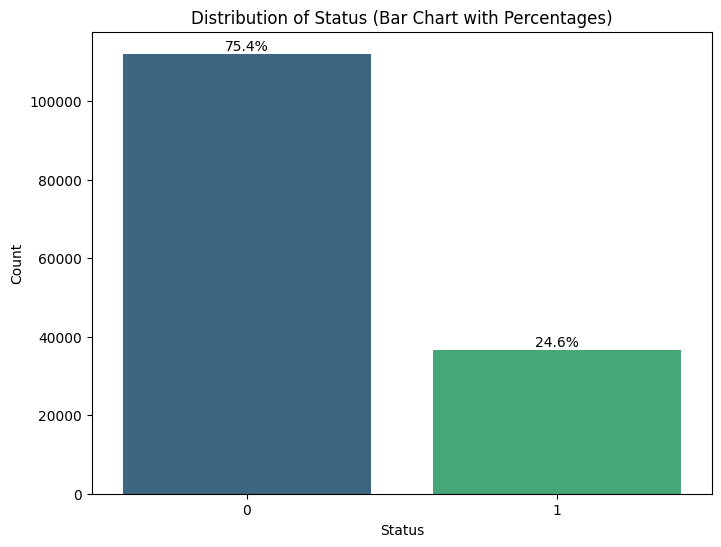

In [4]:
status_counts = df['Status'].value_counts()

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='Status', palette='viridis')
plt.title('Distribution of Status (Bar Chart with Percentages)')
plt.xlabel('Status')
plt.ylabel('Count')

total = len(df['Status'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [6]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [7]:
df = df.drop_duplicates()

In [8]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,3344
Gender,0
approv_in_adv,908
loan_type,0
loan_purpose,134
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


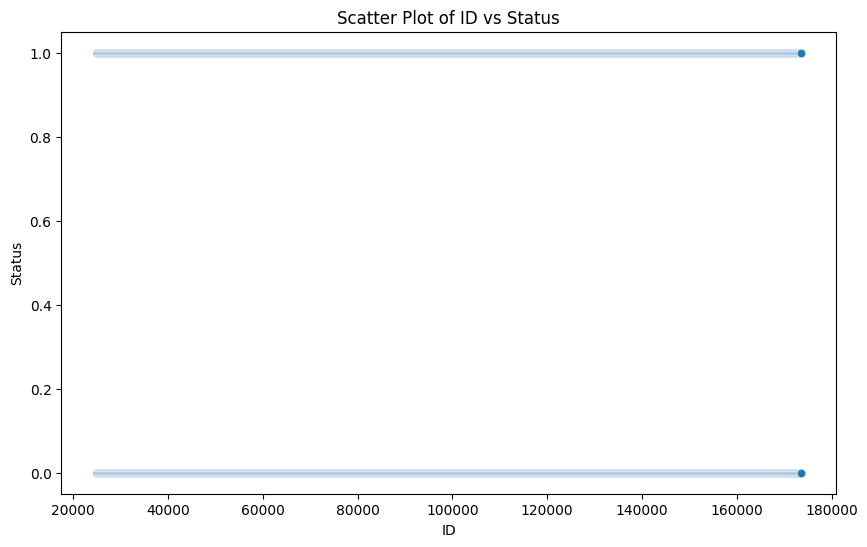

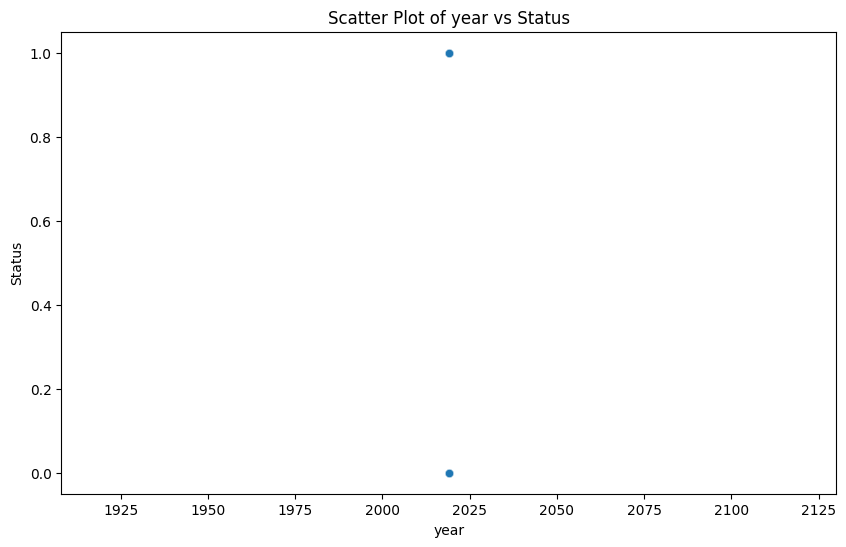

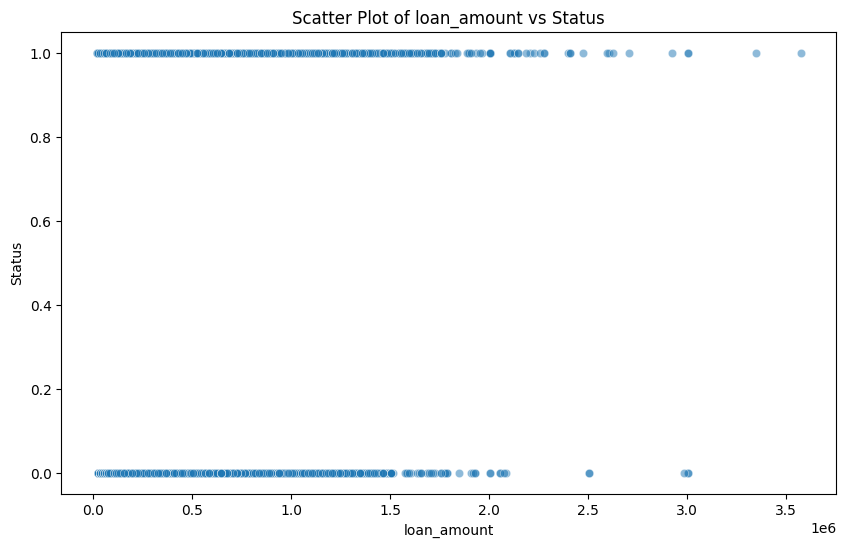

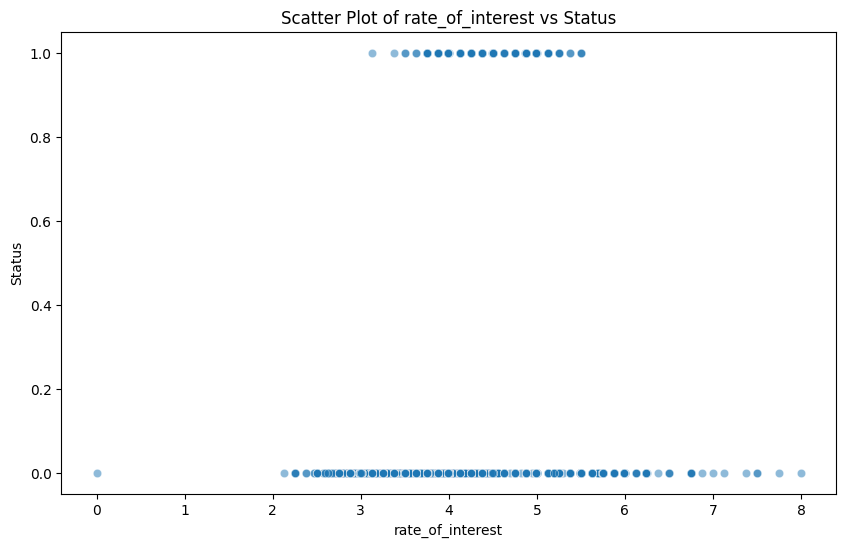

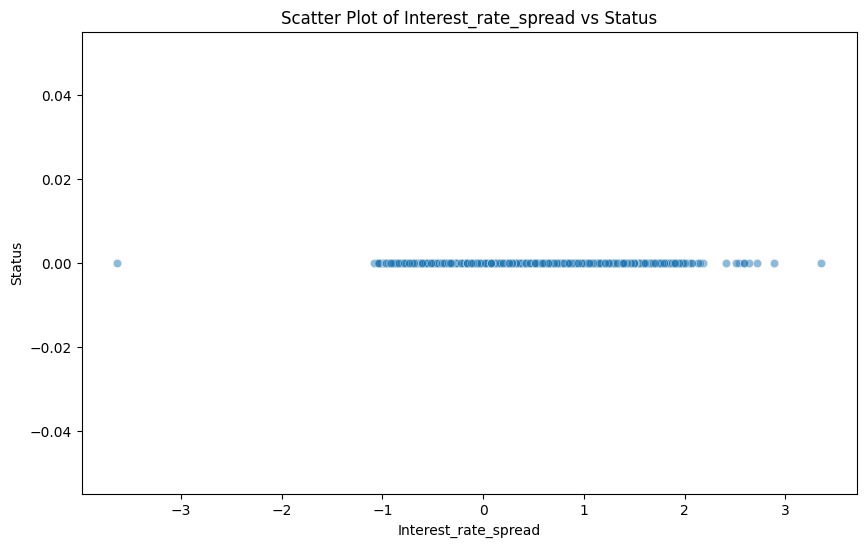

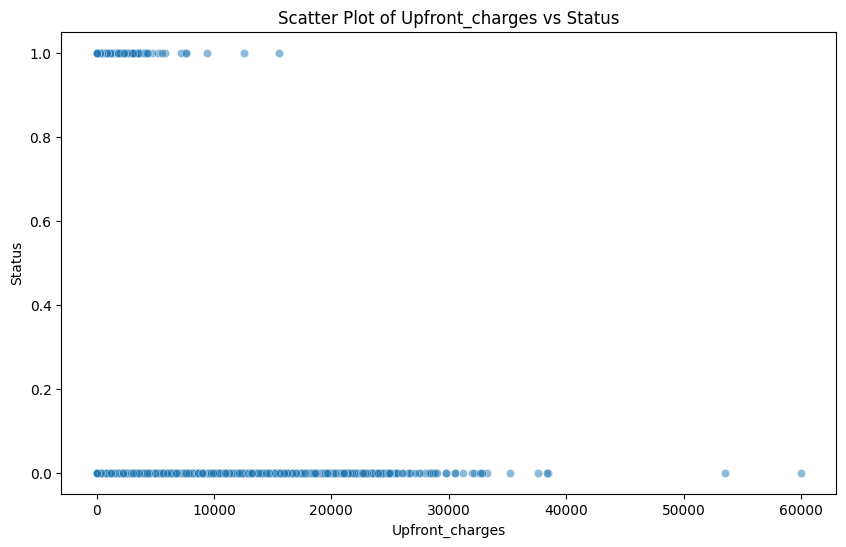

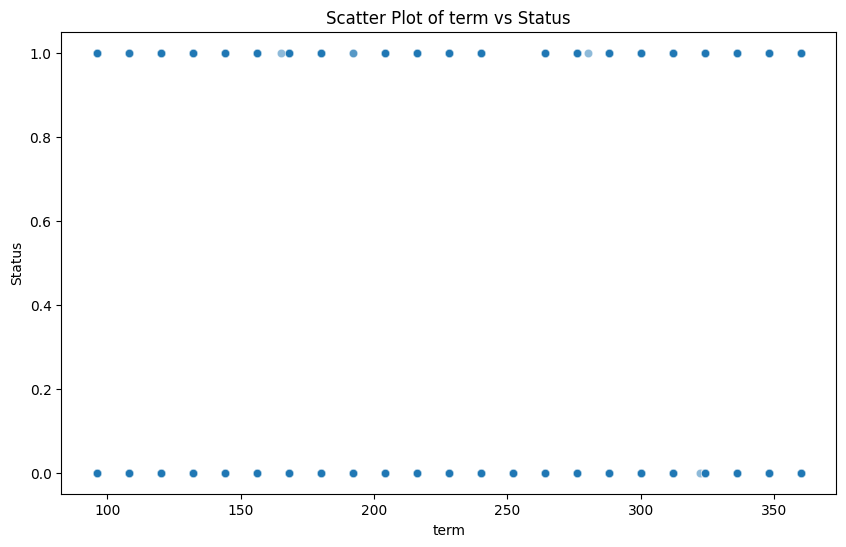

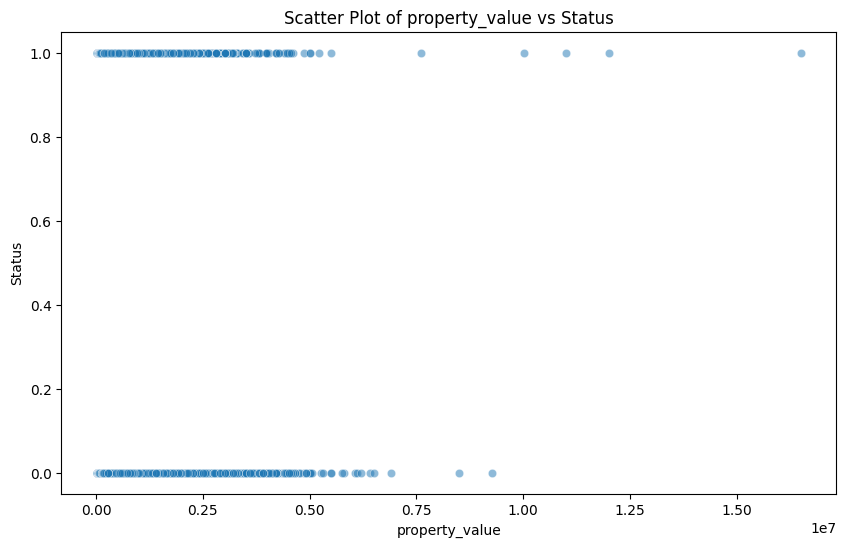

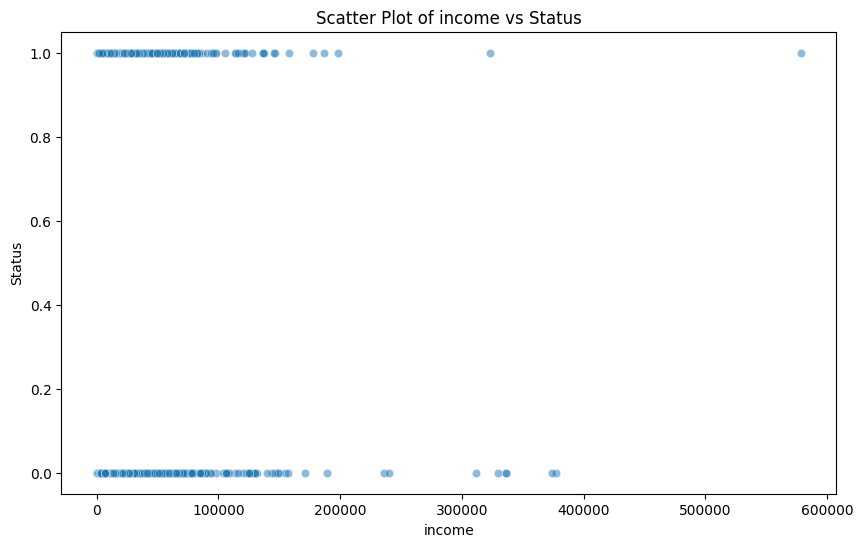

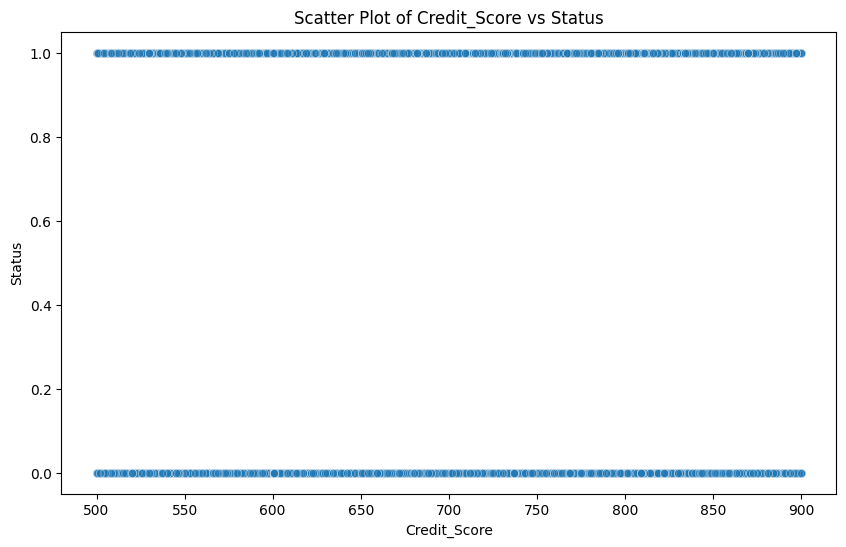

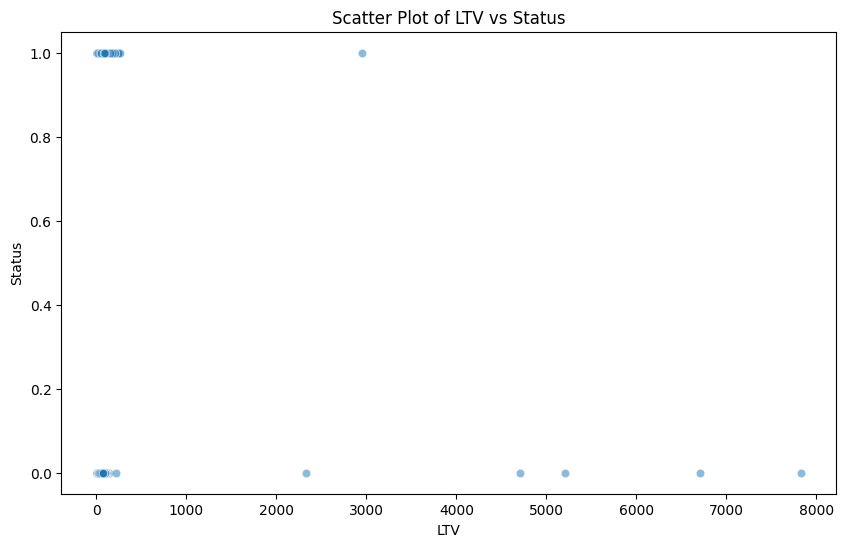

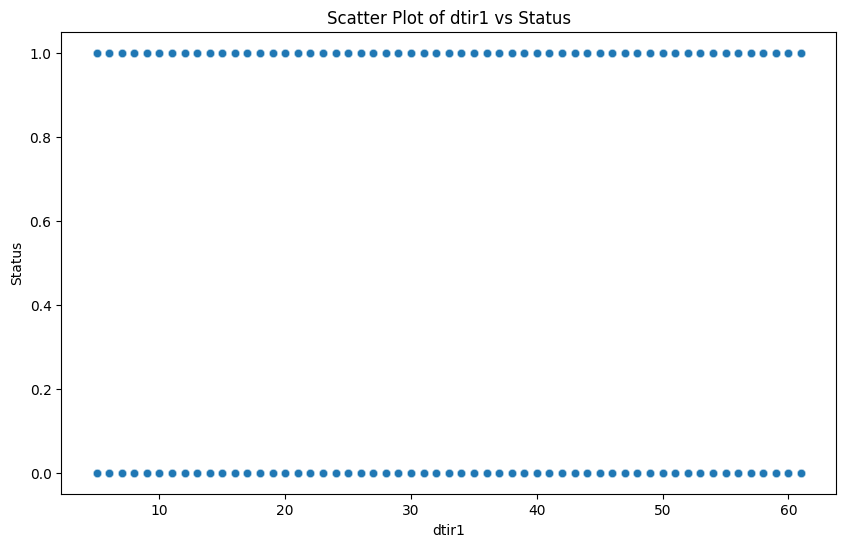

In [9]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols.remove('Status')

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=col, y='Status', alpha=0.5)
    plt.title(f'Scatter Plot of {col} vs Status')
    plt.xlabel(col)
    plt.ylabel('Status')
    plt.show()

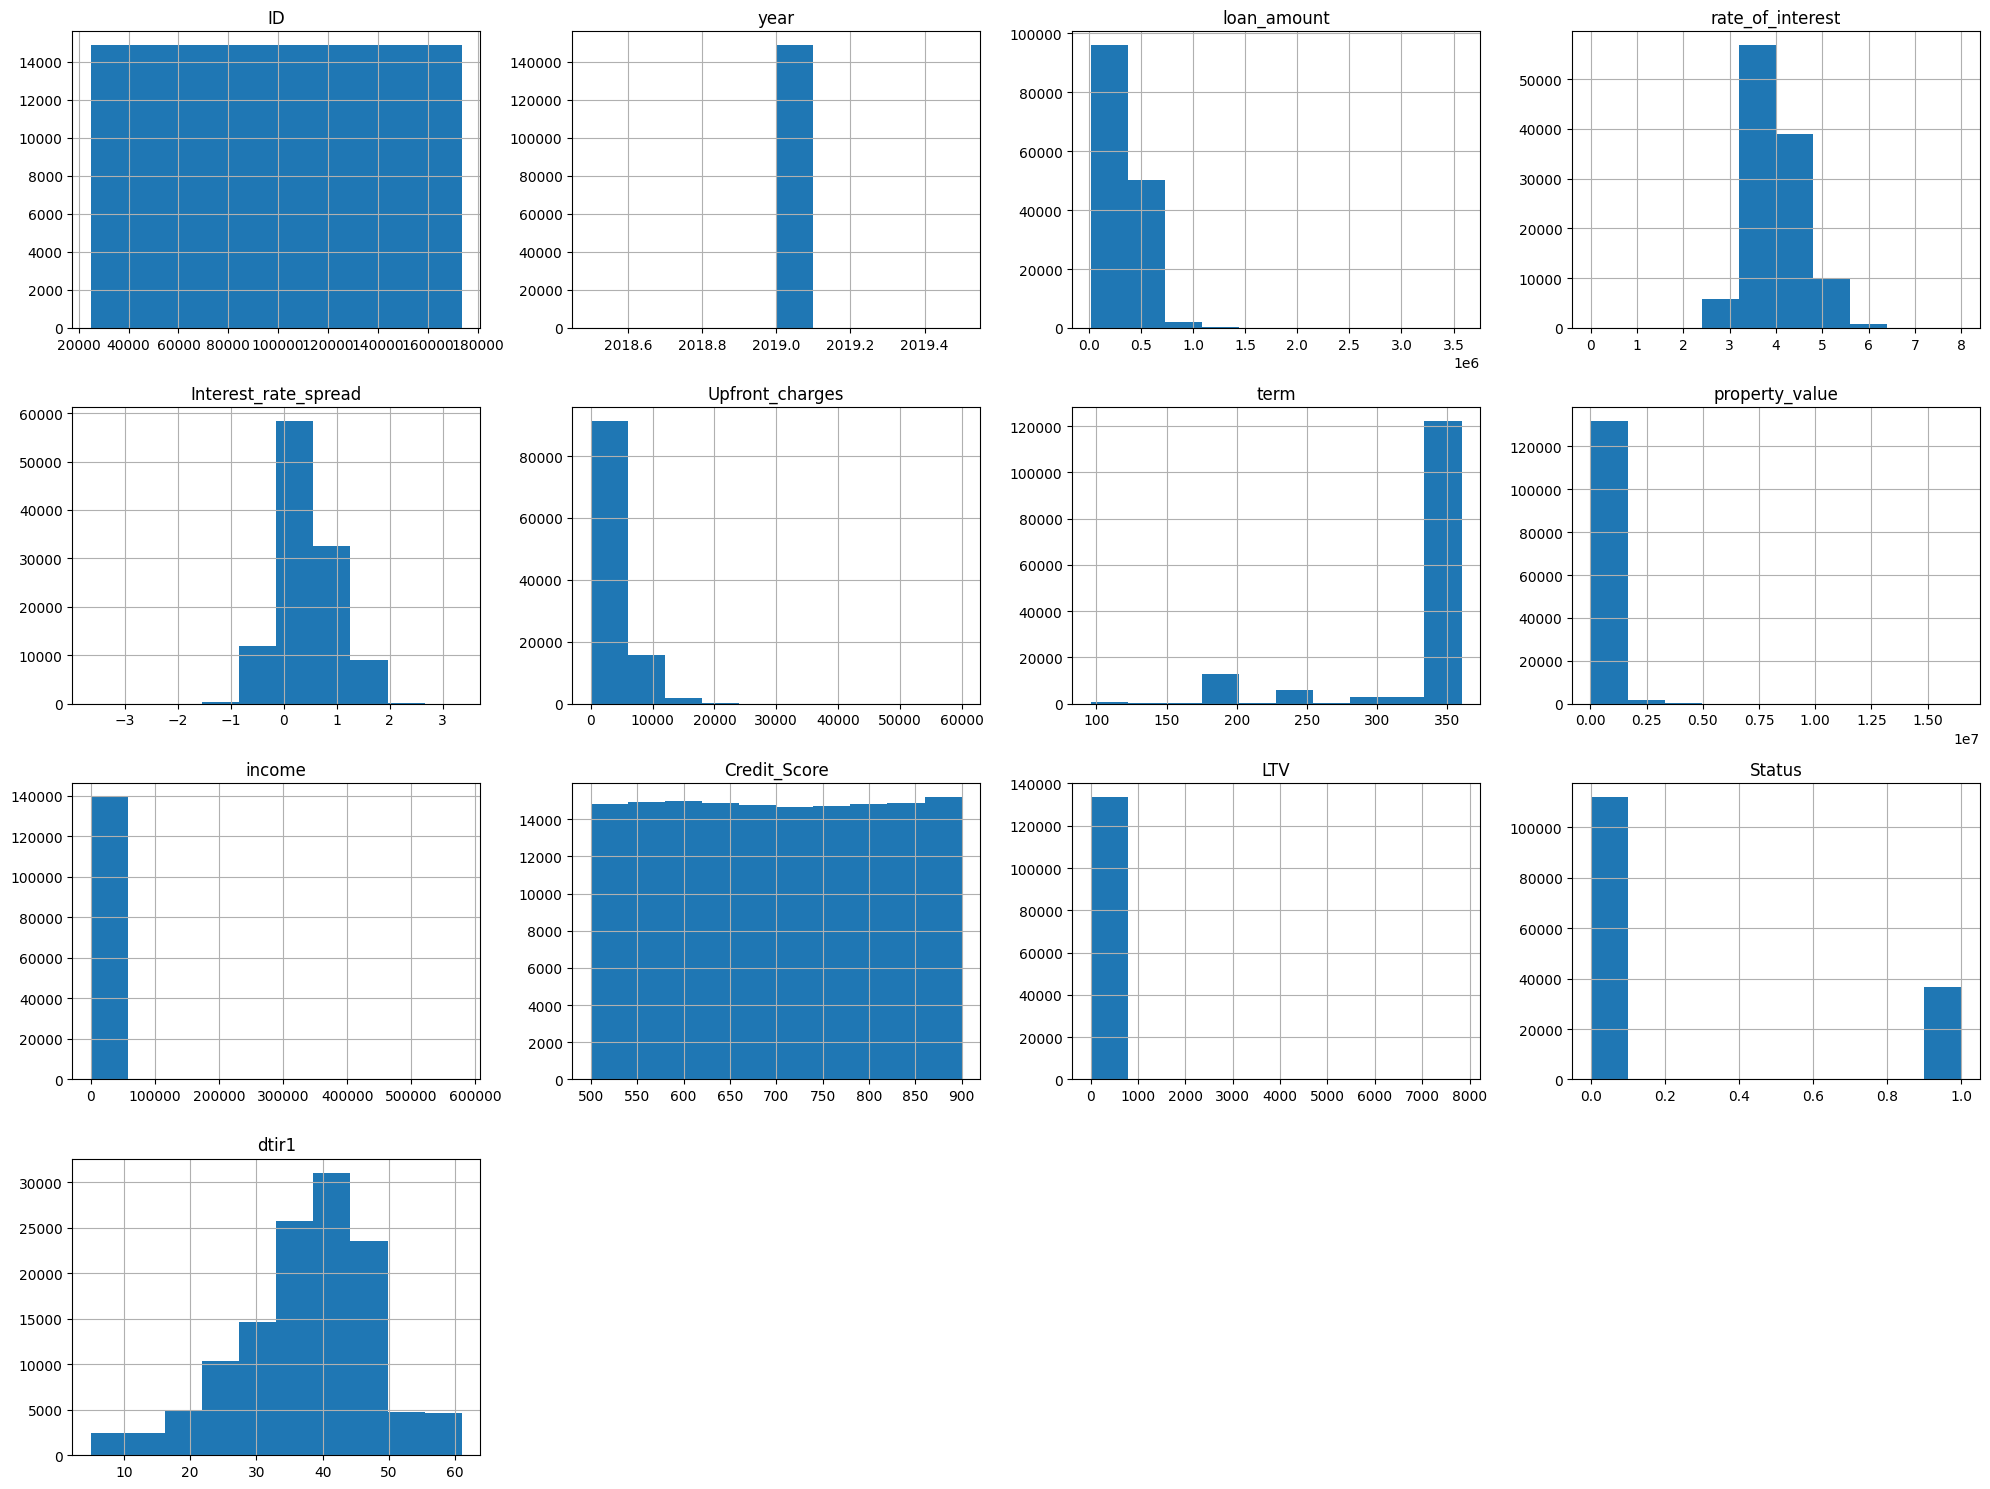

In [10]:
df.hist(figsize=(20, 15))
plt.tight_layout()
plt.show()

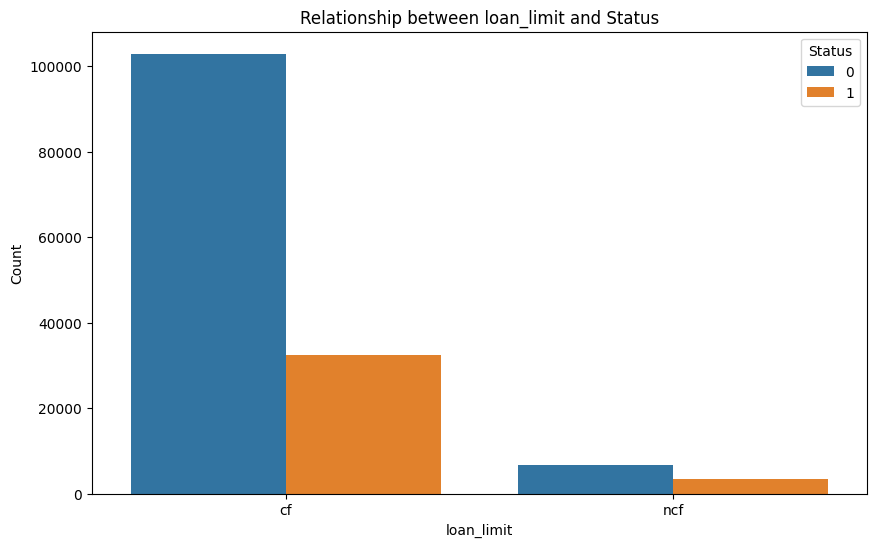

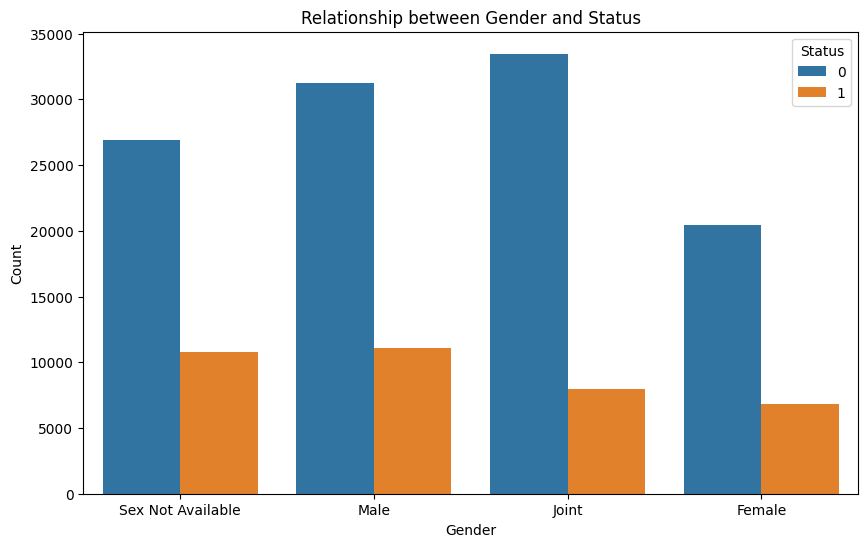

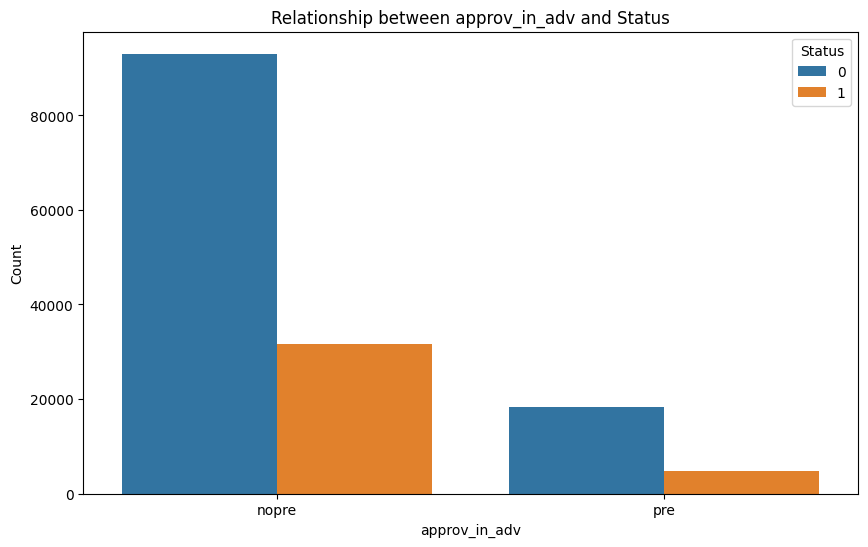

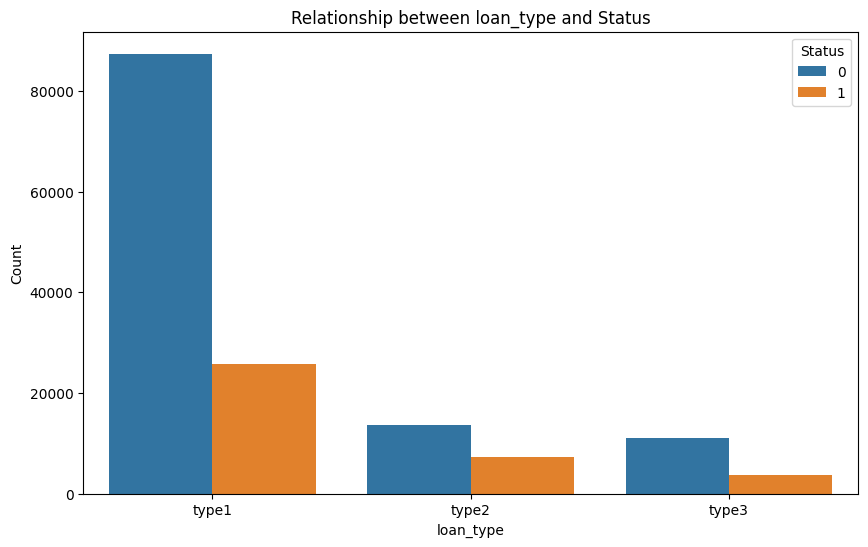

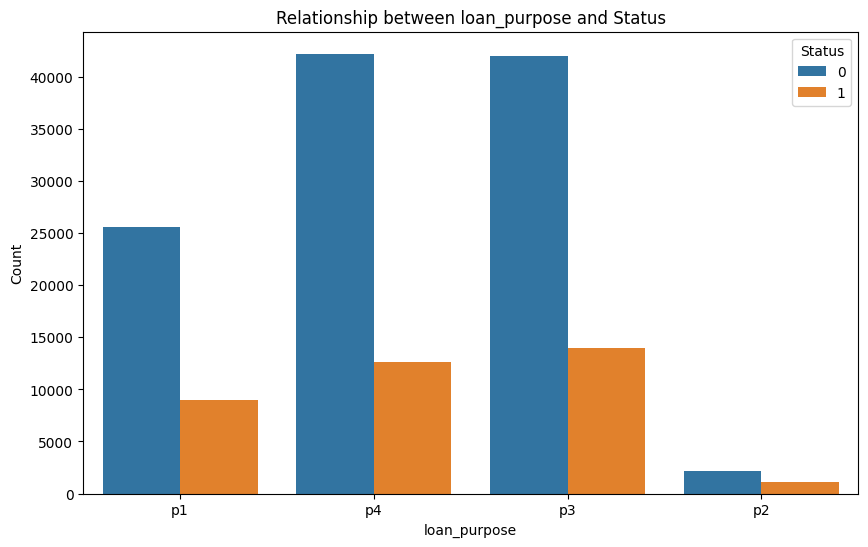

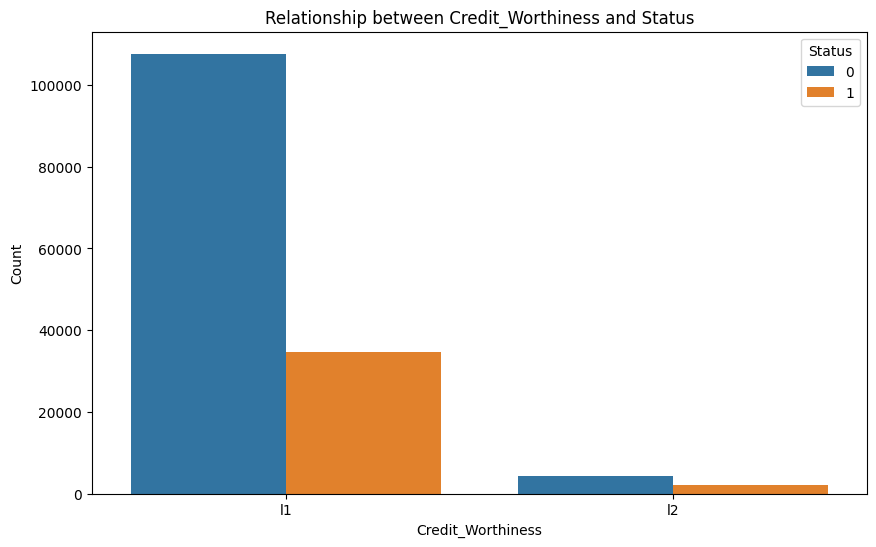

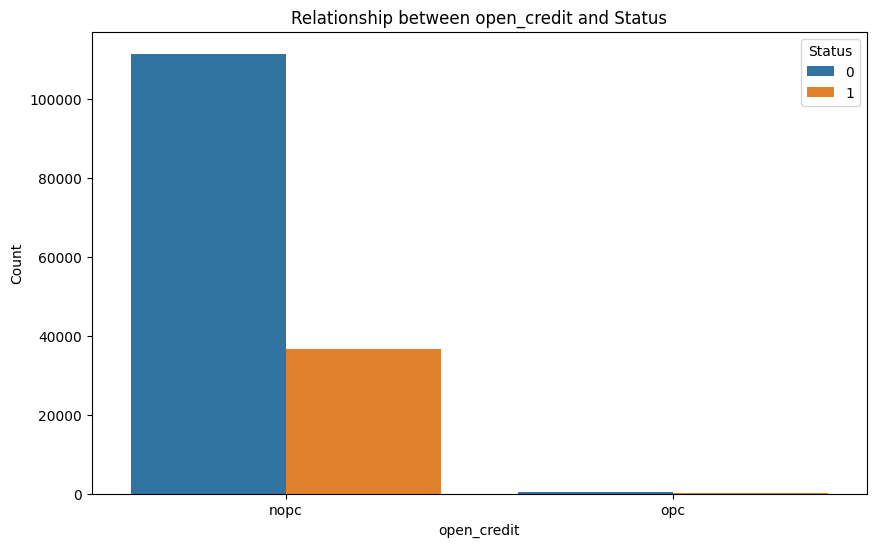

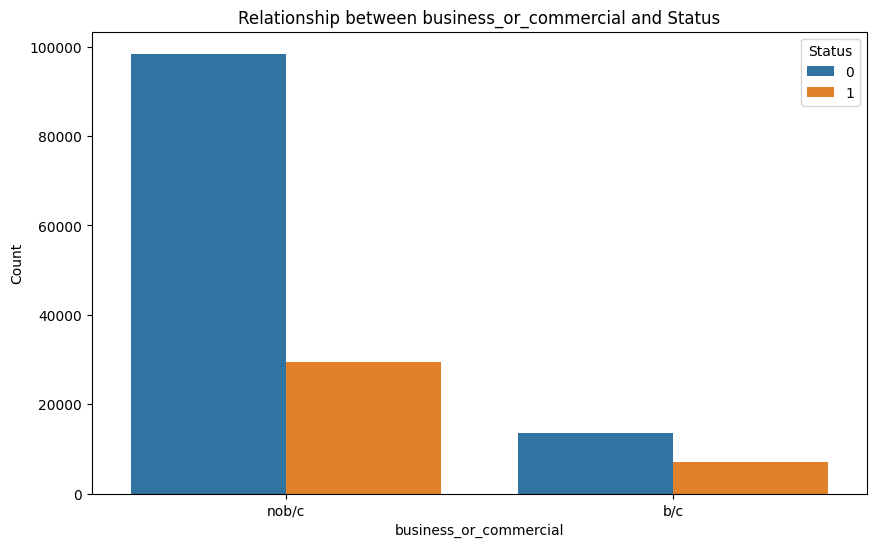

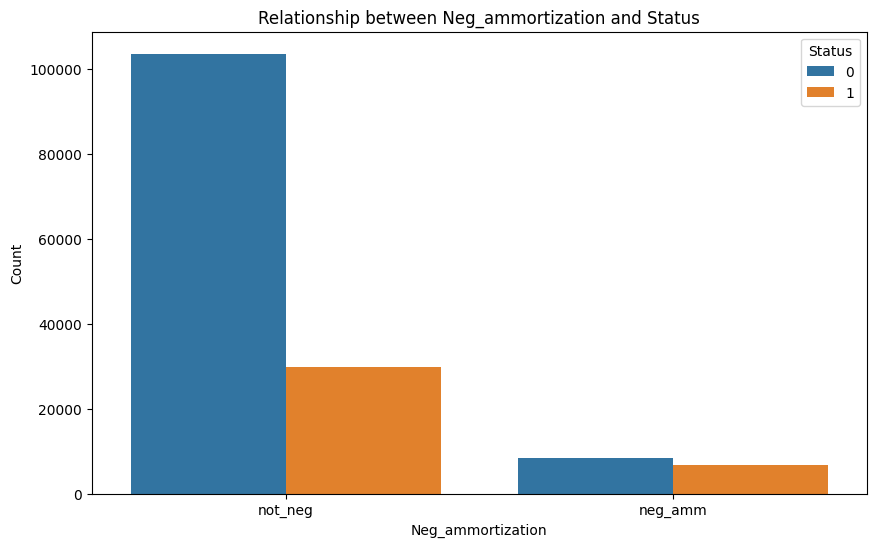

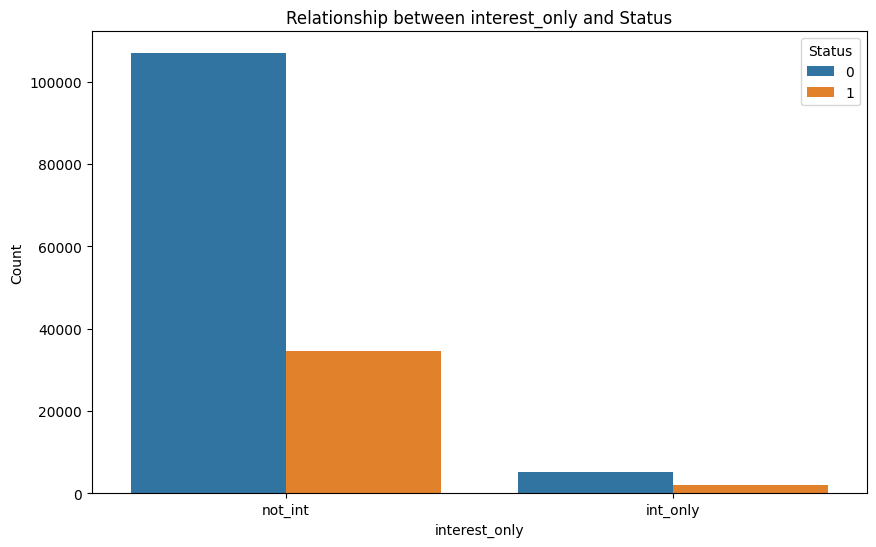

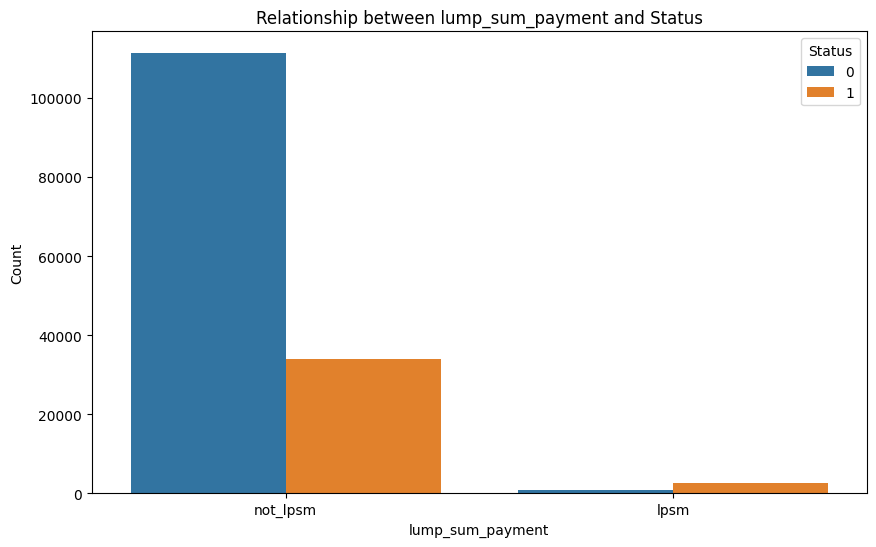

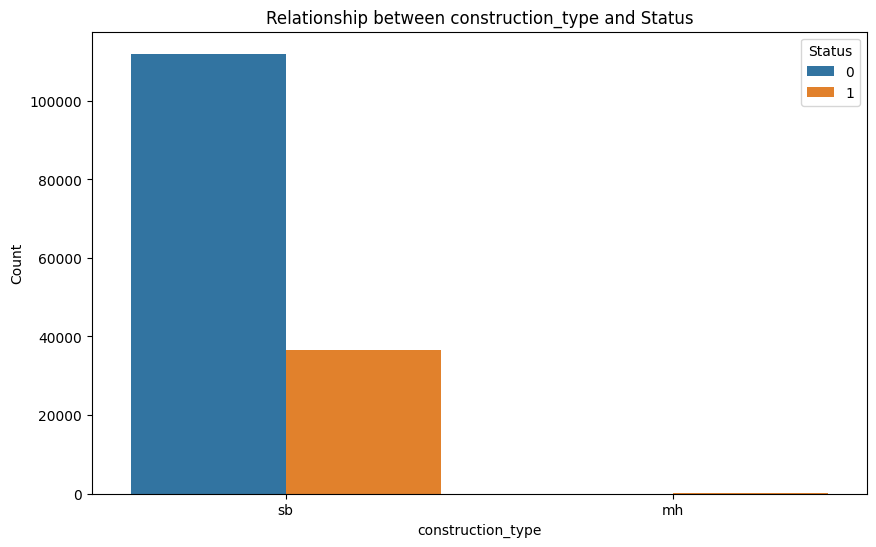

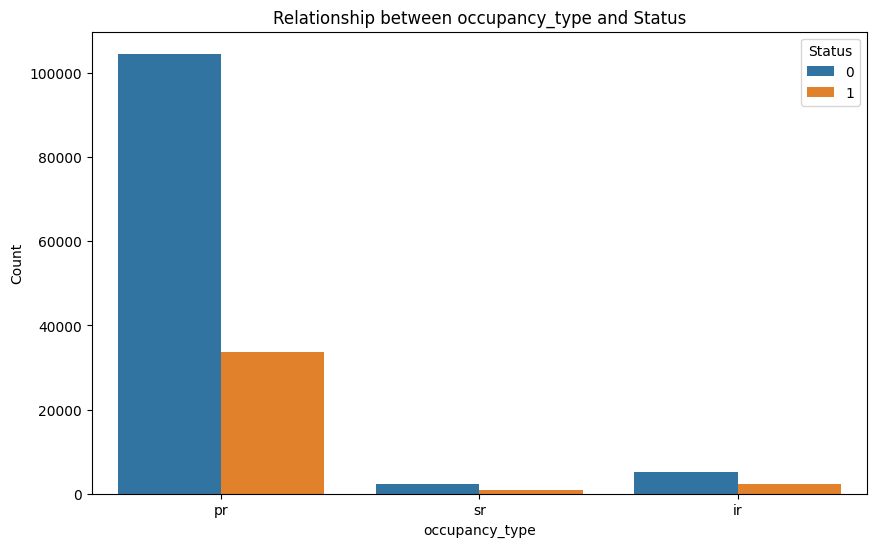

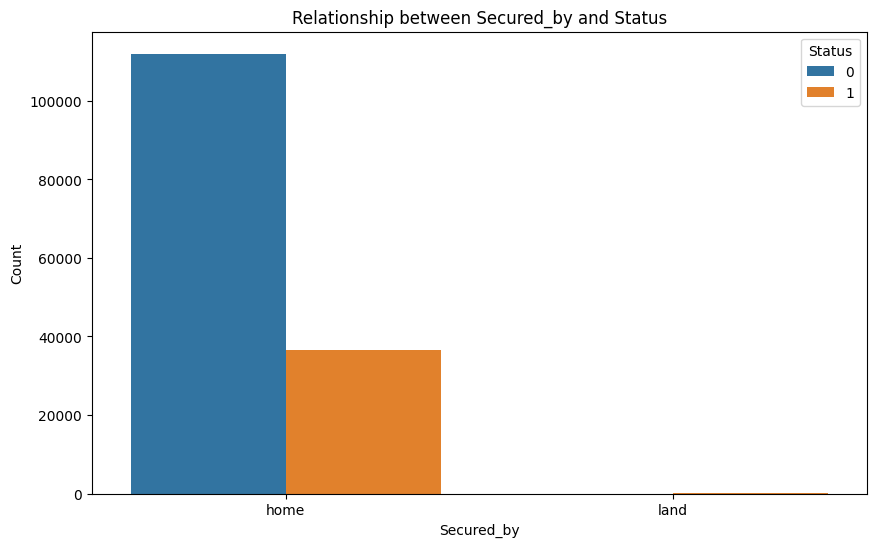

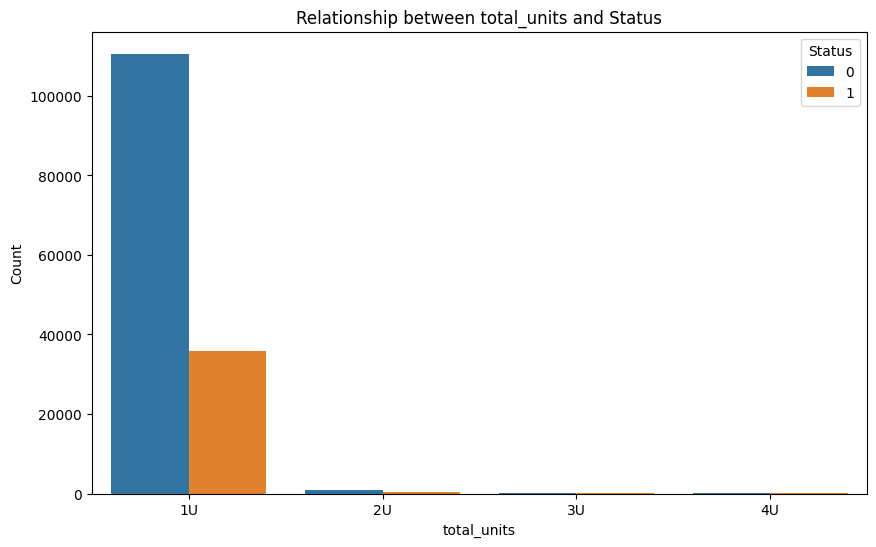

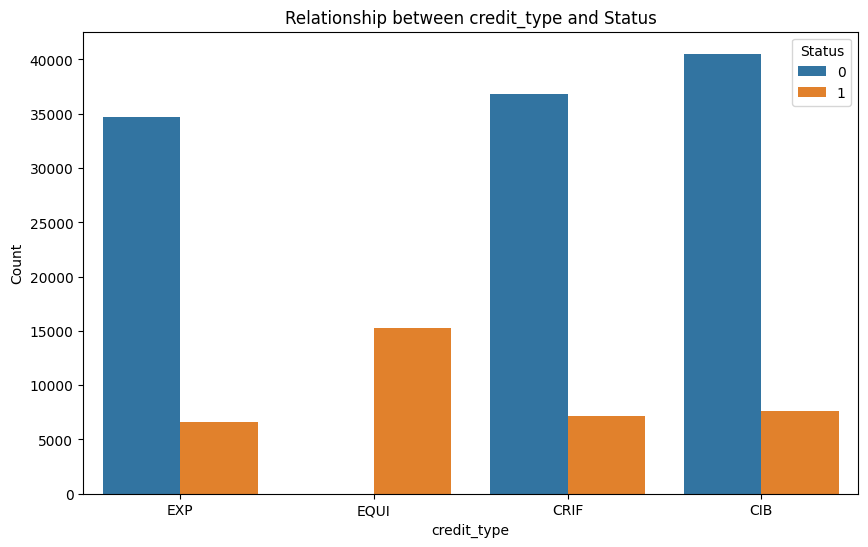

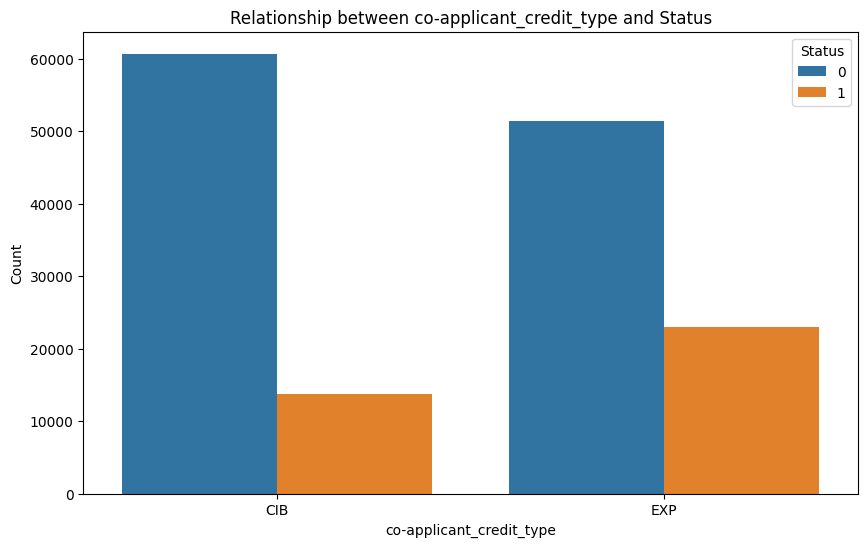

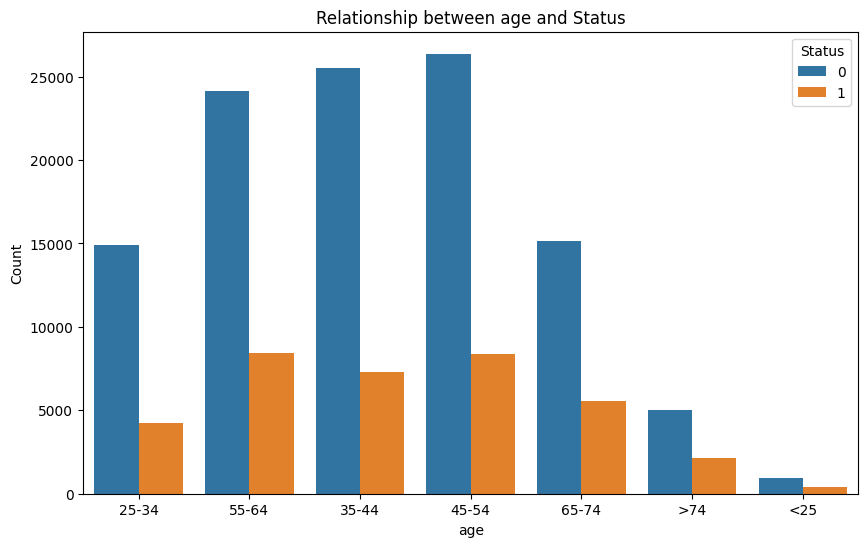

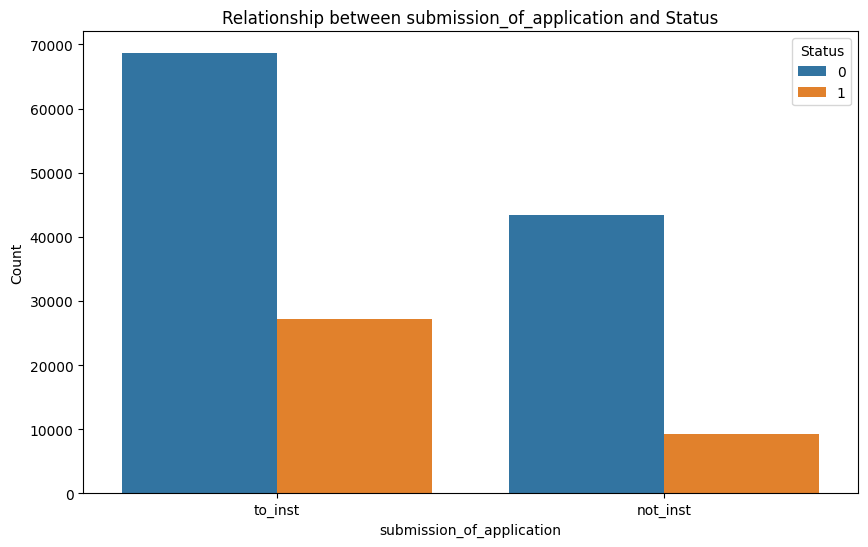

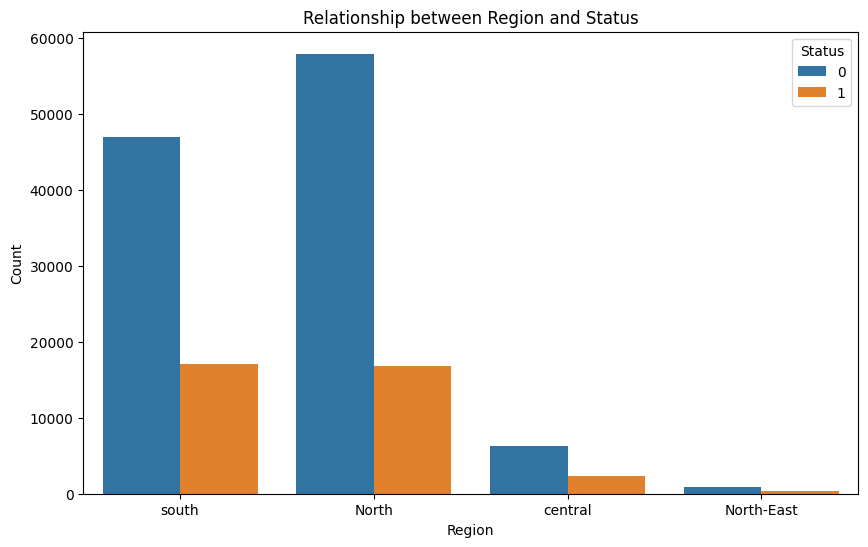

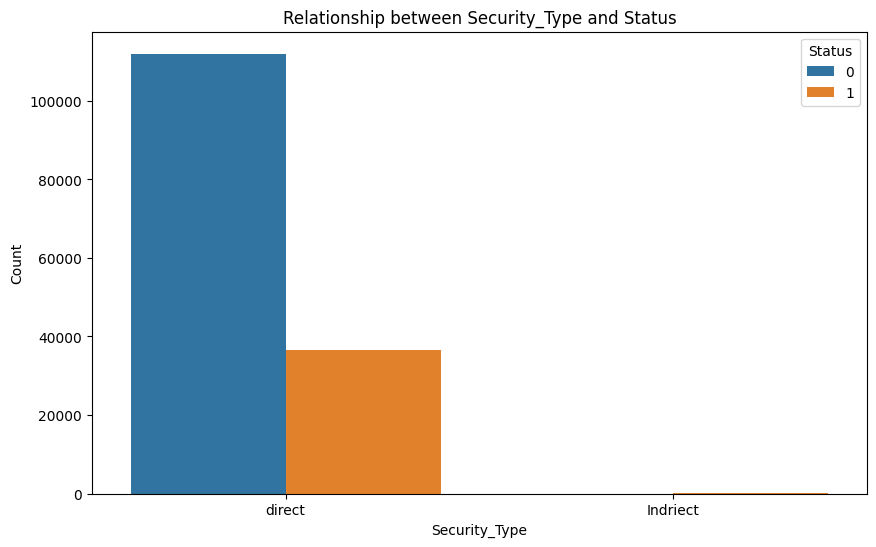

In [11]:
categorical_columns = ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']

for column in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=column, hue='Status')
    plt.title(f'Relationship between {column} and Status')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.show()

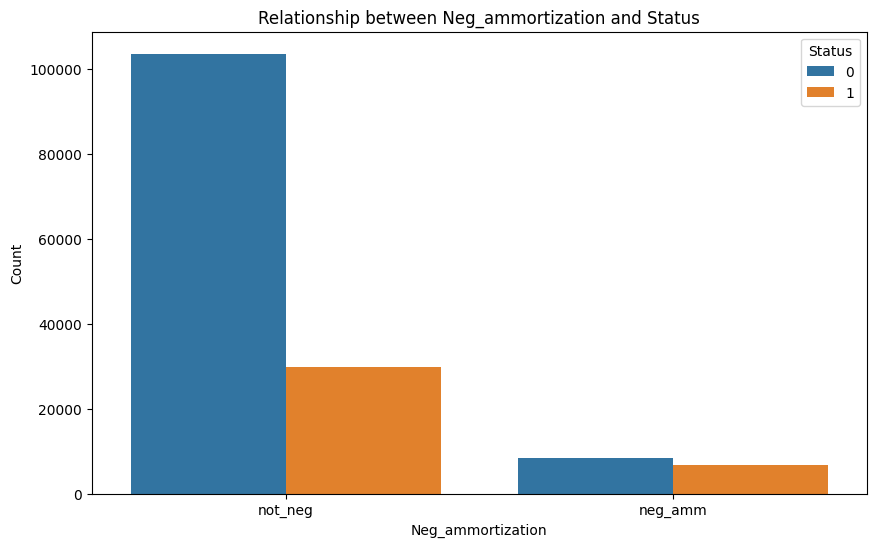

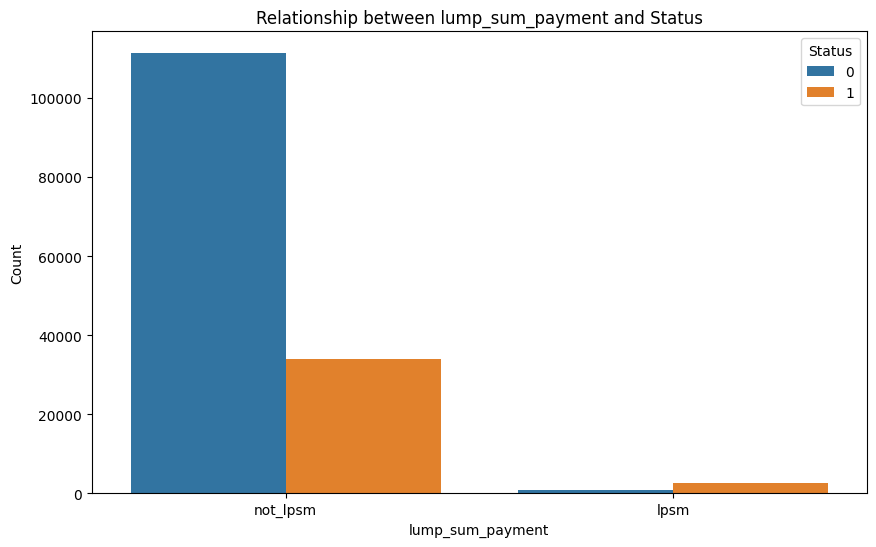

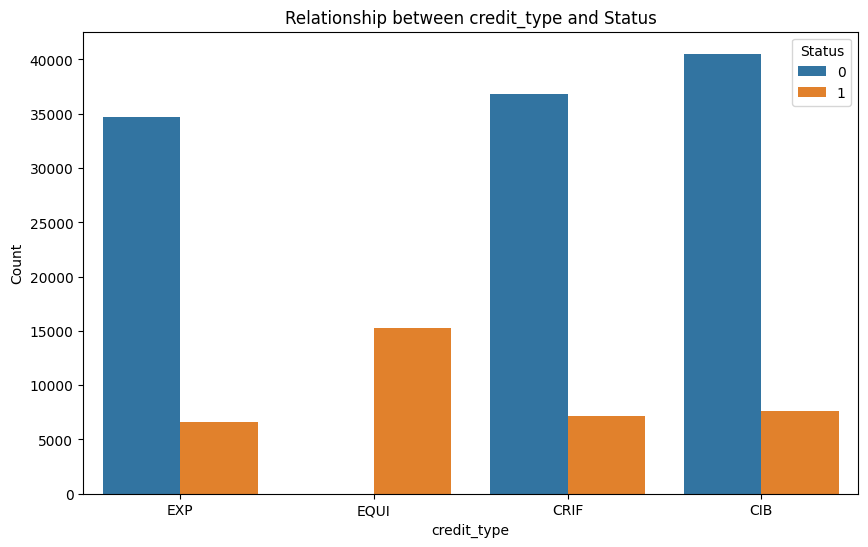

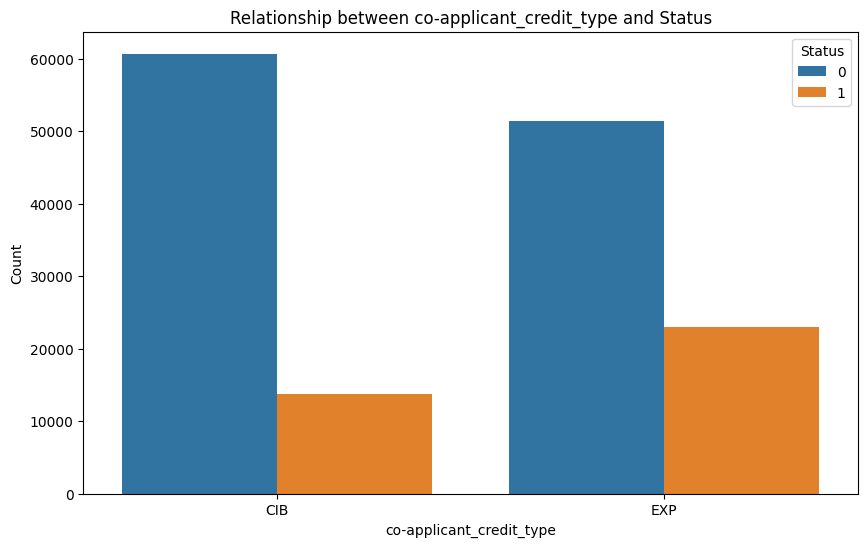

In [12]:
categorical_columns = ['Neg_ammortization', 'lump_sum_payment',  'credit_type', 'co-applicant_credit_type']

for column in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=column, hue='Status')
    plt.title(f'Relationship between {column} and Status')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.show()


--- Visualizing: Upfront_charges ---


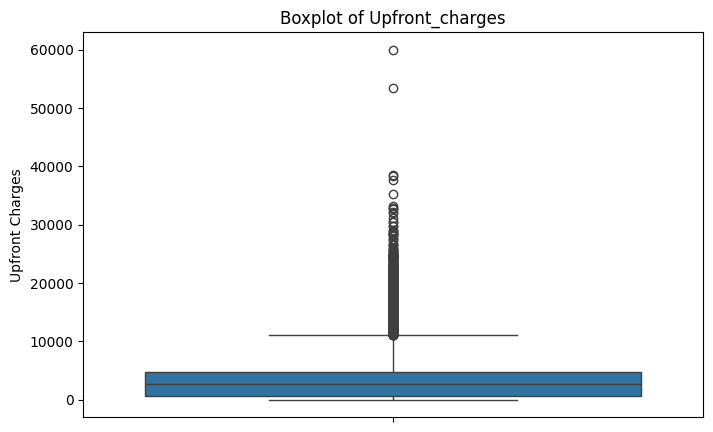

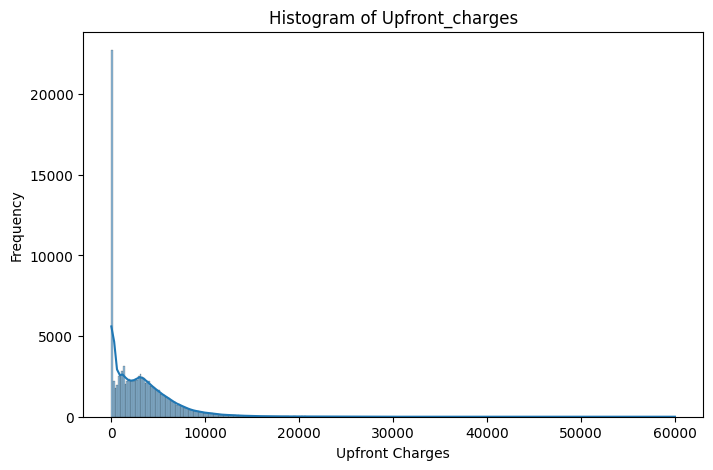


--- Visualizing: property_value ---


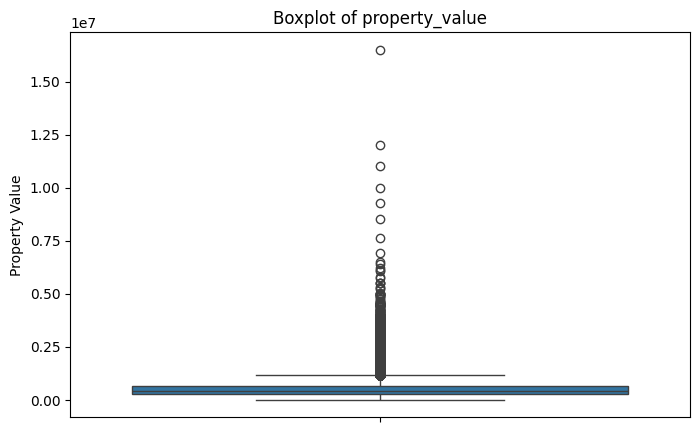

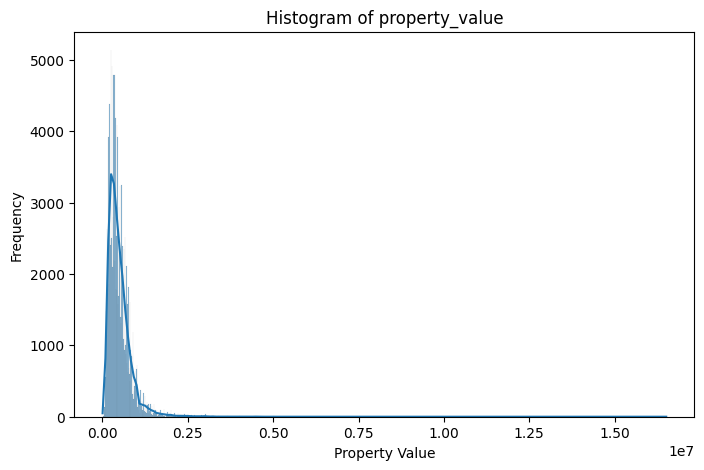

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['Upfront_charges', 'property_value']

for feature in features_to_plot:
    print(f"\n--- Visualizing: {feature} ---")

    # Boxplot
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.ylabel(feature.replace('_', ' ').title())
    plt.show()

    # Histogram
    plt.figure(figsize=(8, 5))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Histogram of {feature}')
    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel('Frequency')
    plt.show()

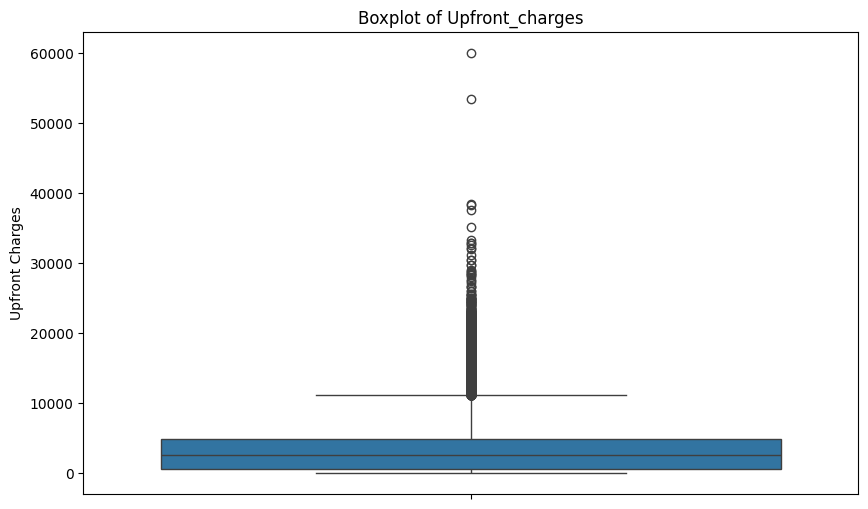

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for Upfront_charges
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Upfront_charges'])
plt.title('Boxplot of Upfront_charges')
plt.ylabel('Upfront Charges')
plt.show()

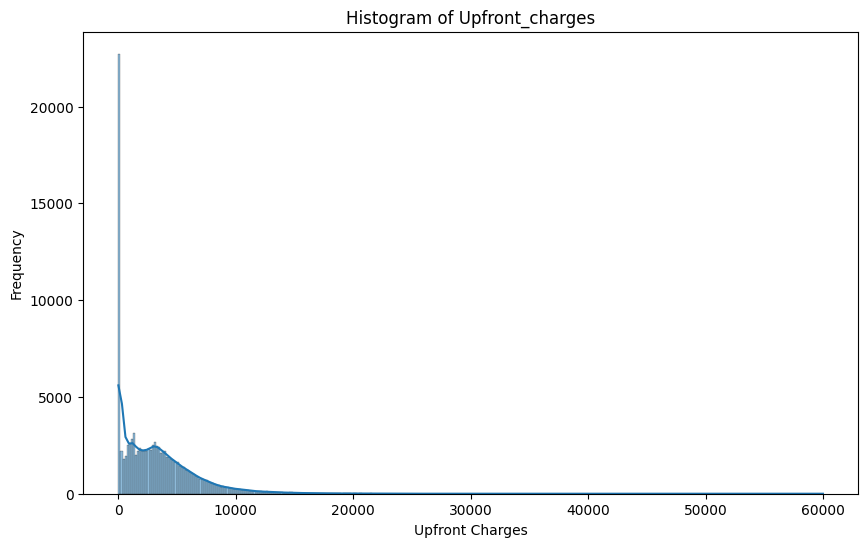

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for Upfront_charges
plt.figure(figsize=(10, 6))
sns.histplot(df['Upfront_charges'], kde=True)
plt.title('Histogram of Upfront_charges')
plt.xlabel('Upfront Charges')
plt.ylabel('Frequency')
plt.show()

In [16]:
df.loan_limit.fillna(df.loan_limit.mode()[0],inplace=True)
df.rate_of_interest.fillna(df.rate_of_interest.mode()[0],inplace=True)
df.Interest_rate_spread.fillna(df.Interest_rate_spread.mode()[0],inplace=True)
df.Upfront_charges.fillna(df.Upfront_charges.mode()[0],inplace=True)
df.property_value.fillna(df.property_value.mode()[0],inplace=True)
df.LTV.fillna(df.LTV.mode()[0],inplace=True)
df.dtir1.fillna(df.dtir1.mode()[0],inplace=True)
df.income.fillna(df.income.mode()[0],inplace=True)

df.dropna(subset=['approv_in_adv'], inplace=True)
df.dropna(subset=['loan_purpose'], inplace=True)
df.dropna(subset=['term'], inplace=True)
df.dropna(subset=['Neg_ammortization'], inplace=True)
df.dropna(subset=['age'], inplace=True)
df.dropna(subset=['submission_of_application'], inplace=True)

In [17]:
df.isnull().sum()

,0
ID,0
year,0
loan_limit,0
Gender,0
approv_in_adv,0
loan_type,0
loan_purpose,0
Credit_Worthiness,0
open_credit,0
business_or_commercial,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147274 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         147274 non-null  int64  
 1   year                       147274 non-null  int64  
 2   loan_limit                 147274 non-null  object 
 3   Gender                     147274 non-null  object 
 4   approv_in_adv              147274 non-null  object 
 5   loan_type                  147274 non-null  object 
 6   loan_purpose               147274 non-null  object 
 7   Credit_Worthiness          147274 non-null  object 
 8   open_credit                147274 non-null  object 
 9   business_or_commercial     147274 non-null  object 
 10  loan_amount                147274 non-null  int64  
 11  rate_of_interest           147274 non-null  float64
 12  Interest_rate_spread       147274 non-null  float64
 13  Upfront_charges            147274 

In [19]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()

categorical_columns = ['loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'credit_type', 'co-applicant_credit_type', 'age', 'submission_of_application', 'Region', 'Security_Type']

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 147274 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         147274 non-null  int64  
 1   year                       147274 non-null  int64  
 2   loan_limit                 147274 non-null  int64  
 3   Gender                     147274 non-null  int64  
 4   approv_in_adv              147274 non-null  int64  
 5   loan_type                  147274 non-null  int64  
 6   loan_purpose               147274 non-null  int64  
 7   Credit_Worthiness          147274 non-null  int64  
 8   open_credit                147274 non-null  int64  
 9   business_or_commercial     147274 non-null  int64  
 10  loan_amount                147274 non-null  int64  
 11  rate_of_interest           147274 non-null  float64
 12  Interest_rate_spread       147274 non-null  float64
 13  Upfront_charges            147274 

In [21]:
df = df.drop(columns=["ID"])
df = df.drop(columns=["year"])

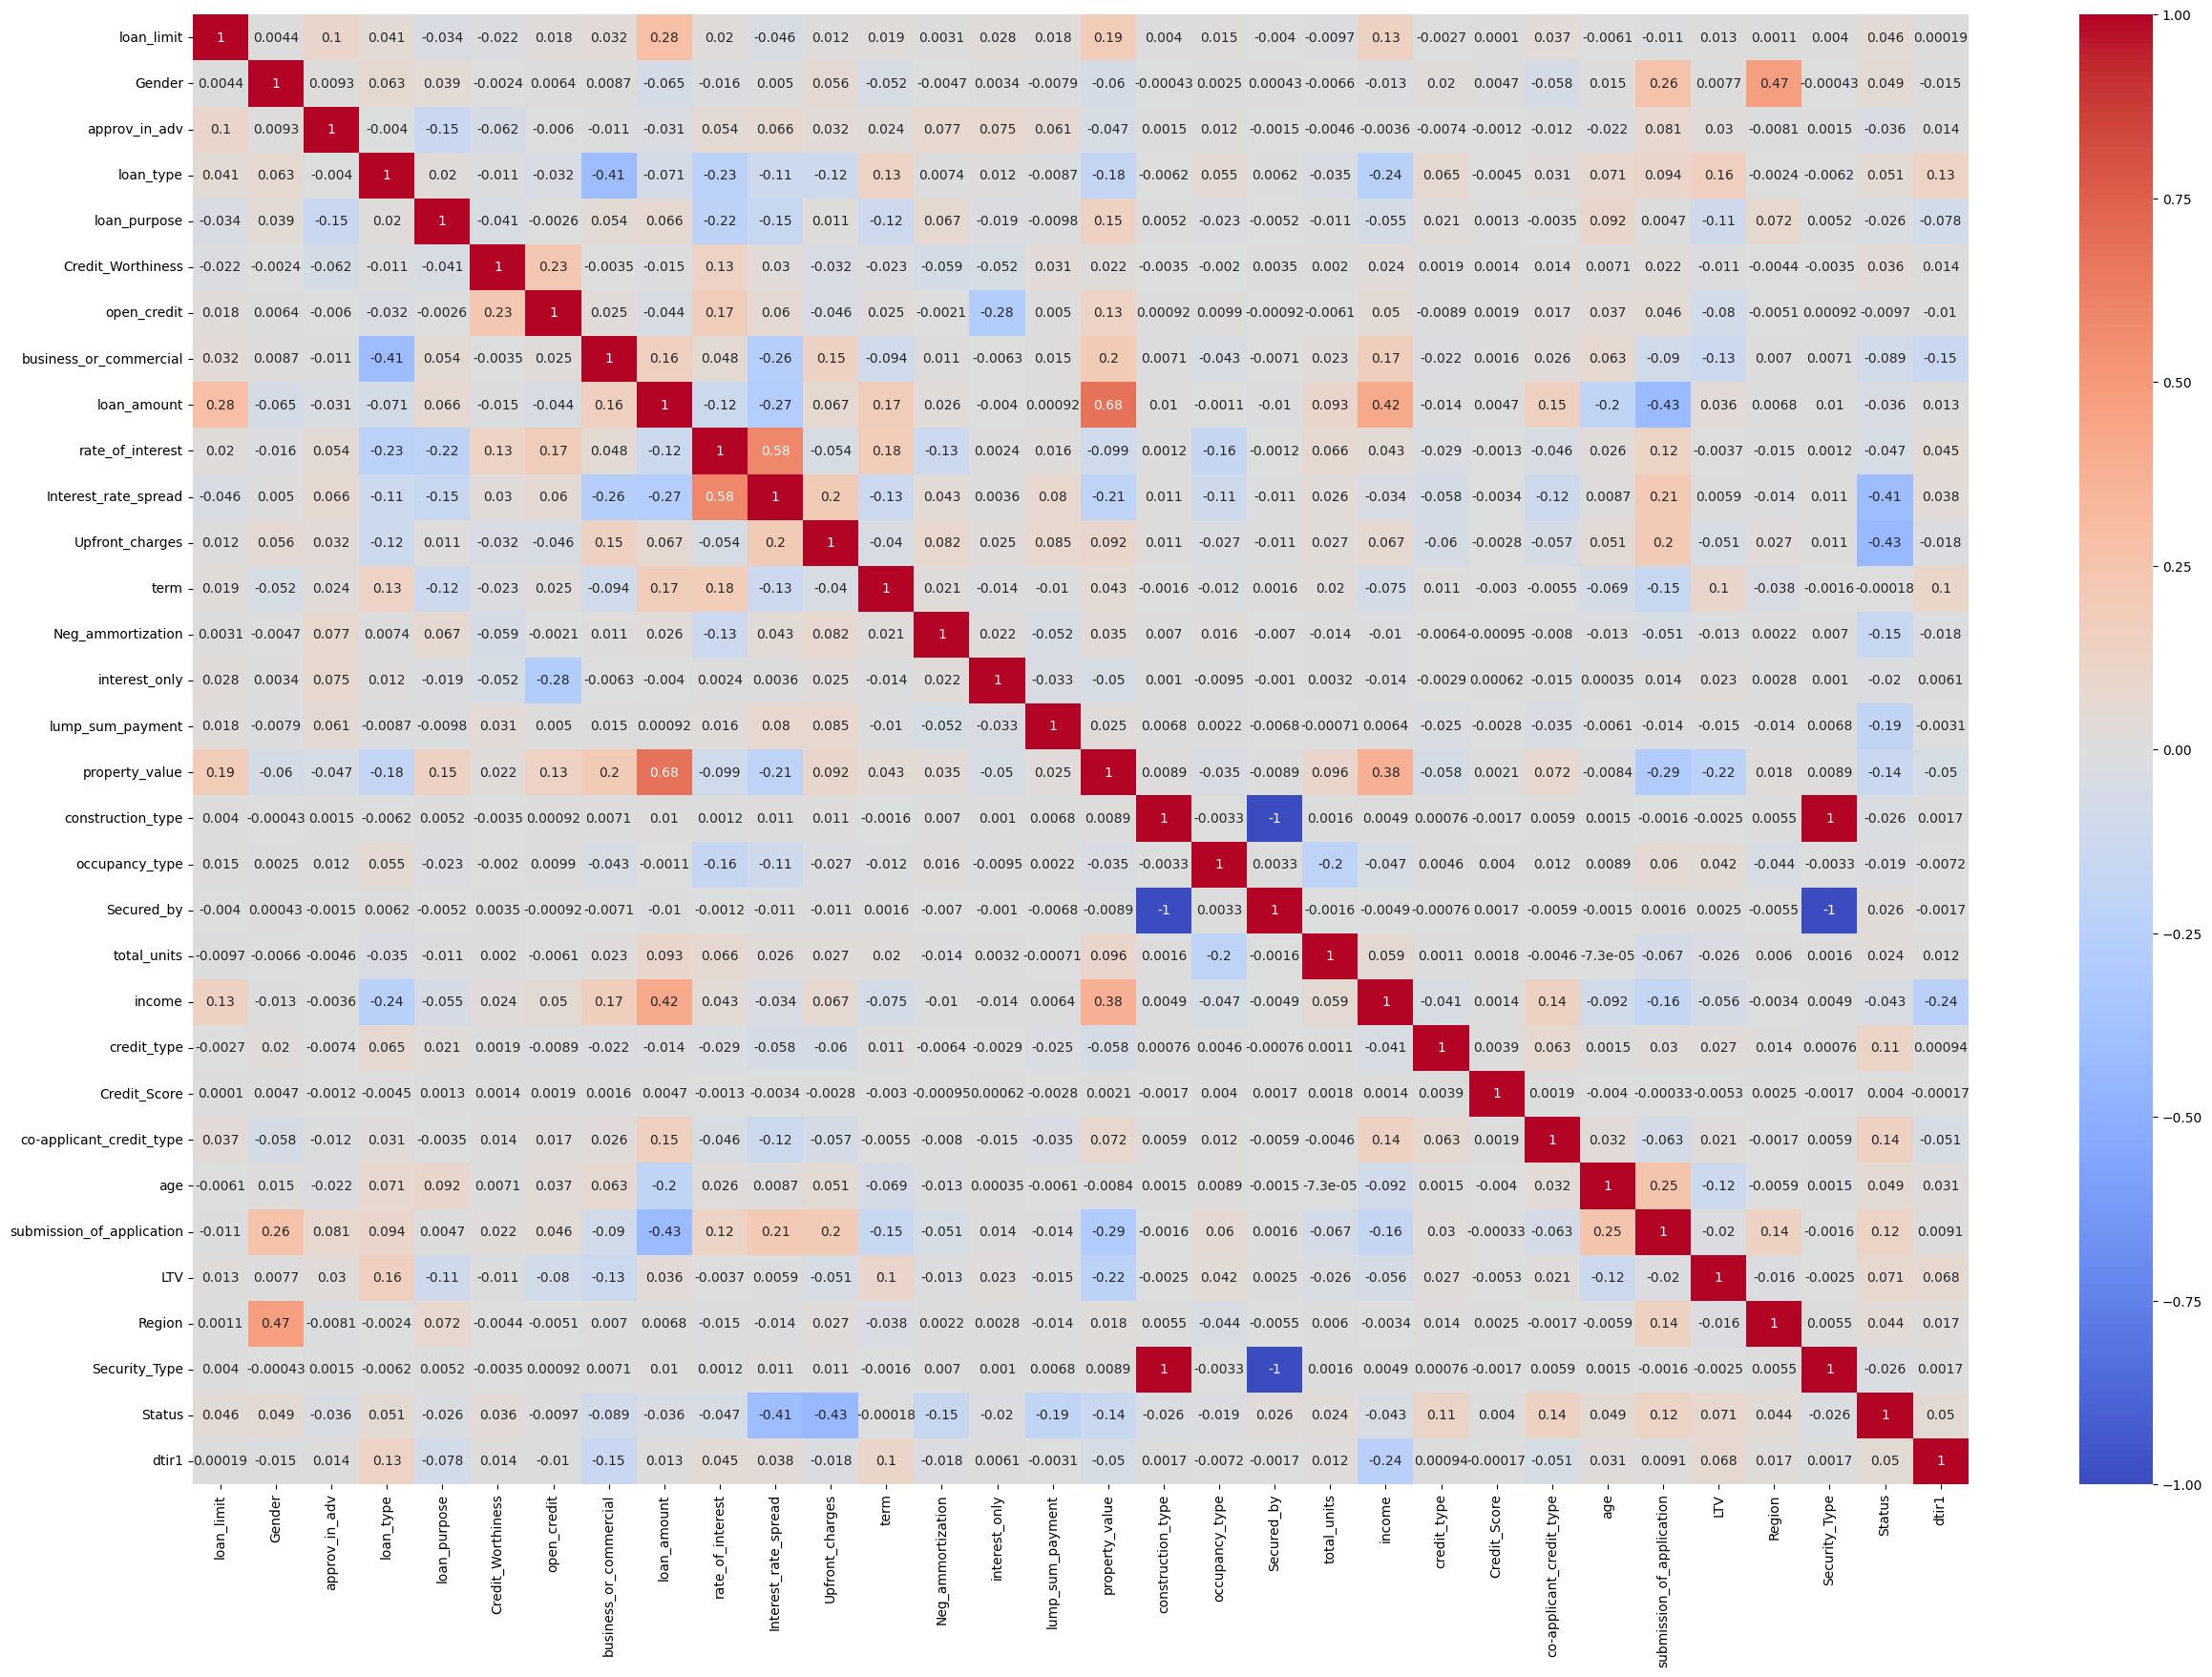

In [22]:
plt.figure(figsize=(30,20))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

### Data preprocessing

In [23]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

Y = df["Status"]

selected_features = ['Upfront_charges', 'Neg_ammortization',
                     'lump_sum_payment', 'property_value', 'credit_type',
                     'co-applicant_credit_type' ]
X = df[selected_features]

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)

# print
print("Standardise data:")
print(X_scaled_df.head())


Standardise data:
   Upfront_charges  Neg_ammortization  lump_sum_payment  property_value  \
0        -0.756274           0.336200          0.153356       -1.043681   
1        -0.756274           0.336200         -6.520789       -0.494582   
2        -0.566209          -2.974416          0.153356        0.083418   
3        -0.756274           0.336200          0.153356        0.516918   
4        -0.756274           0.336200          0.153356        0.805918   

   credit_type  co-applicant_credit_type  
0     1.394674                 -0.997857  
1     0.557721                  1.002148  
2     1.394674                 -0.997857  
3     1.394674                 -0.997857  
4    -0.279233                  1.002148  


In [24]:
X_scaled

array([[-0.75627406,  0.33620043,  0.15335568, -1.0436814 ,  1.39467372,
        -0.99785664],
       [-0.75627406,  0.33620043, -6.52078872, -0.49458151,  0.55772059,
         1.00214797],
       [-0.56620913, -2.97441619,  0.15335568,  0.08341838,  1.39467372,
        -0.99785664],
       ...,
       [-0.36444004,  0.33620043,  0.15335568,  0.71921826, -1.11618565,
         1.00214797],
       [ 0.62475688,  0.33620043,  0.15335568, -0.58128149,  1.39467372,
         1.00214797],
       [ 1.16034707,  0.33620043,  0.15335568,  0.22791835, -1.11618565,
        -0.99785664]])

In [25]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.3, random_state=42)

In [26]:
x_train

array([[-0.73296795,  0.33620043,  0.15335568, -0.08998159,  1.39467372,
         1.00214797],
       [-0.75627406,  0.33620043,  0.15335568, -0.66798148,  1.39467372,
        -0.99785664],
       [-0.2222555 ,  0.33620043, -6.52078872,  0.77701825, -0.27923253,
         1.00214797],
       ...,
       [-0.75627406, -2.97441619,  0.15335568, -0.49458151,  0.55772059,
         1.00214797],
       [ 1.0218073 ,  0.33620043,  0.15335568, -0.20558156, -0.27923253,
        -0.99785664],
       [ 1.21078615,  0.33620043,  0.15335568,  0.19901836, -1.11618565,
         1.00214797]])

In [27]:
x_test

array([[-0.75627406,  0.33620043,  0.15335568, -1.01478141,  1.39467372,
        -0.99785664],
       [-0.75627406,  0.33620043,  0.15335568, -0.14778157,  1.39467372,
        -0.99785664],
       [ 1.33244367,  0.33620043,  0.15335568, -0.40788152,  1.39467372,
        -0.99785664],
       ...,
       [ 0.32501011,  0.33620043,  0.15335568, -0.35008154, -1.11618565,
        -0.99785664],
       [-0.14934404,  0.33620043,  0.15335568, -0.23448156,  1.39467372,
        -0.99785664],
       [ 0.52147336,  0.33620043,  0.15335568, -0.26338155,  1.39467372,
         1.00214797]])

In [28]:
y_train

,Status
11702,0
45774,0
33823,0
143684,0
133096,0
...,...
121027,1
104681,1
133185,1
148260,0


In [29]:
y_test

,Status
64078,0
133870,0
126345,0
31501,0
136015,0
...,...
21184,0
75418,0
94613,0
29796,0


### Models

##### Logistic Regression

Logistic Regression Model Performance (Class Weight)
Accuracy: 0.8779
ROC-AUC Score: 0.9487
F1 Score: 0.7729
Number of features used: 6

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     33312
           1       0.71      0.84      0.77     10871

    accuracy                           0.88     44183
   macro avg       0.83      0.87      0.84     44183
weighted avg       0.89      0.88      0.88     44183


Confusion Matrix:
[[29614  3698]
 [ 1695  9176]]

Top 10 Most Important Features:
                 Feature  Coefficient  Absolute_Coefficient
         Upfront_charges   -28.512941             28.512941
          property_value    -0.509357              0.509357
        lump_sum_payment    -0.365982              0.365982
       Neg_ammortization    -0.348210              0.348210
co-applicant_credit_type     0.213122              0.213122
             credit_type     0.148573              0.148573


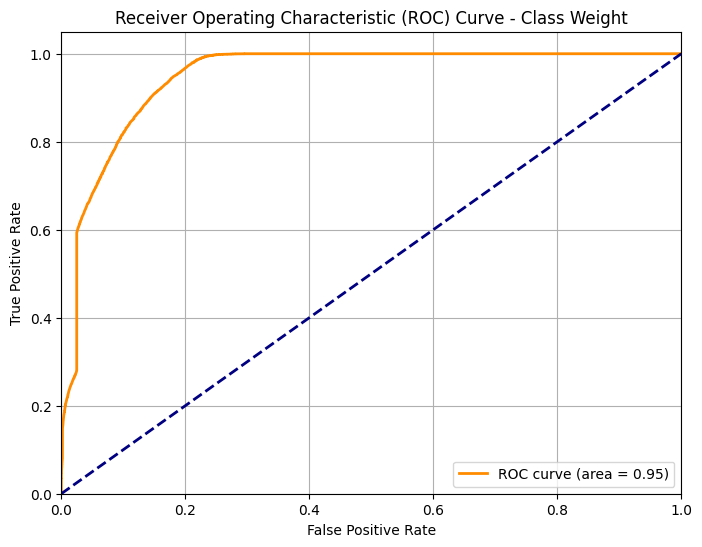

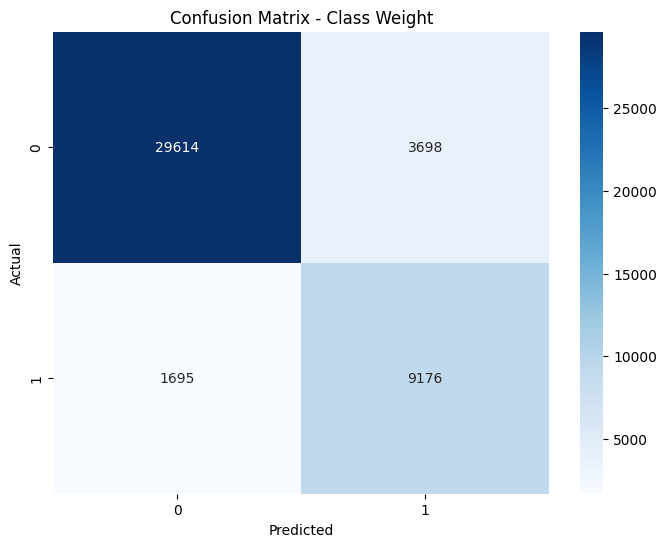

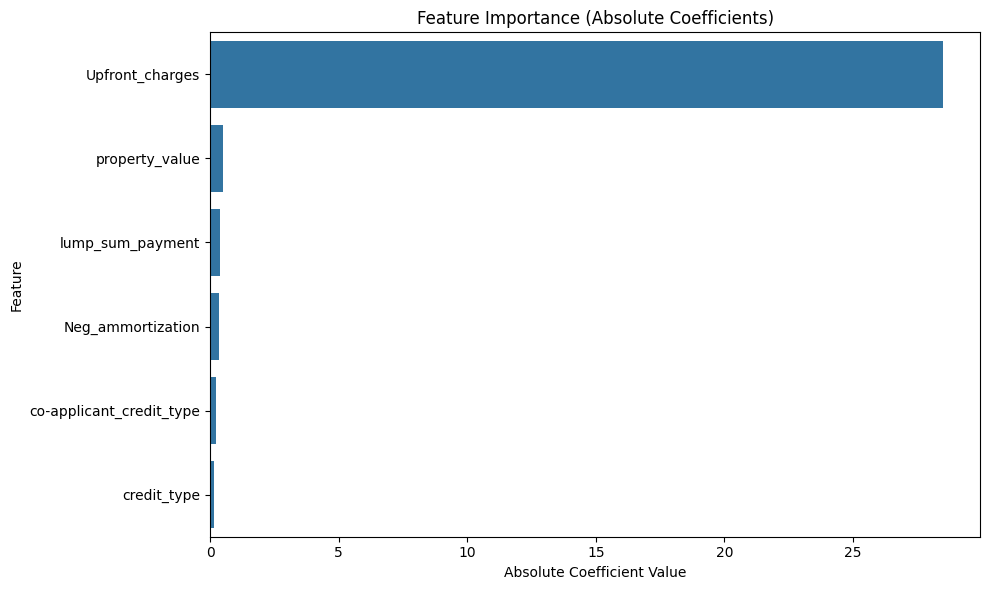

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =====================================
# Logistic Regression with class_weight
# =====================================

# Build Logistic Regression model using class weights
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='liblinear',
    class_weight='balanced'
)
model.fit(x_train, y_train)

# Predict probabilities and labels
y_pred_proba = model.predict_proba(x_test)[:, 1]
y_pred = (y_pred_proba >=0.75).astype(int)   # Threshold can be tuned if needed

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Model Performance (Class Weight)")
print("=" * 60)
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Number of features used: {len(selected_features)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display feature importance
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model.coef_[0],
    'Absolute_Coefficient': np.abs(model.coef_[0])
}).sort_values('Absolute_Coefficient', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Class Weight')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Confusion Matrix as heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Class Weight')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Absolute_Coefficient', y='Feature')
plt.title('Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



[TEST] Best threshold (maximize F1): 0.7501
[TEST] Precision@best: 0.7128 | Recall@best: 0.8441 | F1@best: 0.7729

Evaluation on TEST with F1-selected threshold
Accuracy: 0.8779
ROC-AUC : 0.9487
F1      : 0.7729

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     33312
           1       0.71      0.84      0.77     10871

    accuracy                           0.88     44183
   macro avg       0.83      0.87      0.84     44183
weighted avg       0.89      0.88      0.88     44183


Confusion Matrix:
[[29614  3698]
 [ 1695  9176]]


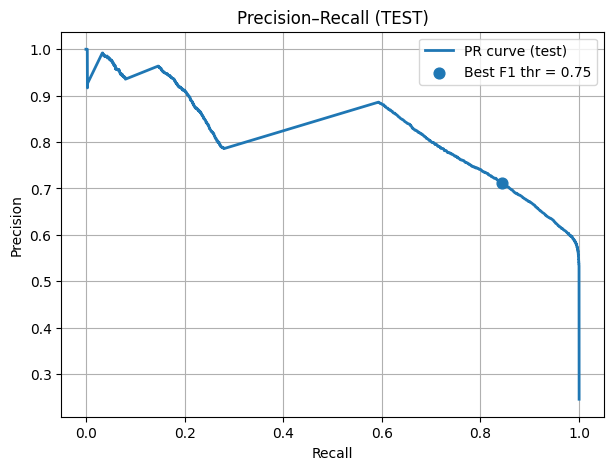

In [49]:
# ===============================
# Find best threshold ON TEST SET
# (leakage by design as requested)
# ===============================
from sklearn.metrics import precision_recall_curve, roc_curve

# ---- Best threshold by F1 on test (from PR curve) ----
prec, rec, thr_pr = precision_recall_curve(y_test, y_pred_proba)  # len(thr_pr) = len(prec)-1
f1_vals = 2 * prec * rec / (prec + rec + 1e-12)

best_idx_f1 = np.argmax(f1_vals[:-1]) if len(thr_pr) else 0
best_thr_f1 = float(thr_pr[best_idx_f1]) if len(thr_pr) else 0.5
print(f"\n[TEST] Best threshold (maximize F1): {best_thr_f1:.4f}")
print(f"[TEST] Precision@best: {prec[best_idx_f1]:.4f} | Recall@best: {rec[best_idx_f1]:.4f} | F1@best: {f1_vals[best_idx_f1]:.4f}")

y_pred_best_f1 = (y_pred_proba >= best_thr_f1).astype(int)

print("\nEvaluation on TEST with F1-selected threshold")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_f1):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}")  # AUC unchanged by threshold
print(f"F1      : {f1_score(y_test, y_pred_best_f1):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_f1))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_f1))

# (Optional) visualize PR curve and best point
plt.figure(figsize=(7,5))
plt.plot(rec, prec, lw=2, label='PR curve (test)')
plt.scatter(rec[best_idx_f1], prec[best_idx_f1], s=60, marker='o',
            label=f'Best F1 thr = {best_thr_f1:.2f}', zorder=5)
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision–Recall (TEST)')
plt.legend(); plt.grid(True); plt.show()




##### Radom Forest

Random Forest Model Performance
Accuracy : 0.8908
ROC-AUC  : 0.9630
F1-Score : 0.7929
Features : 6

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93     33312
           1       0.74      0.85      0.79     10871

    accuracy                           0.89     44183
   macro avg       0.85      0.88      0.86     44183
weighted avg       0.90      0.89      0.89     44183


Confusion Matrix:
[[30122  3190]
 [ 1635  9236]]


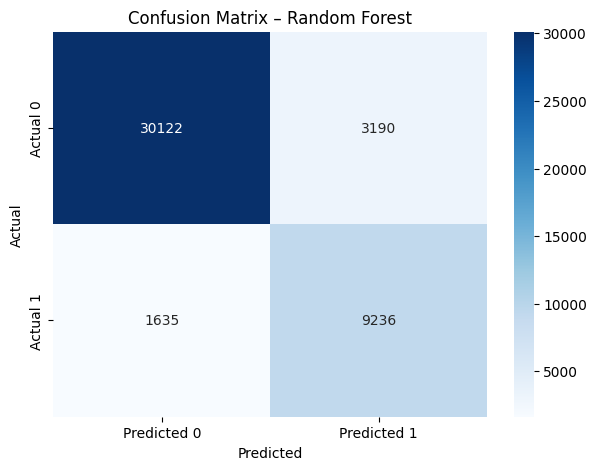

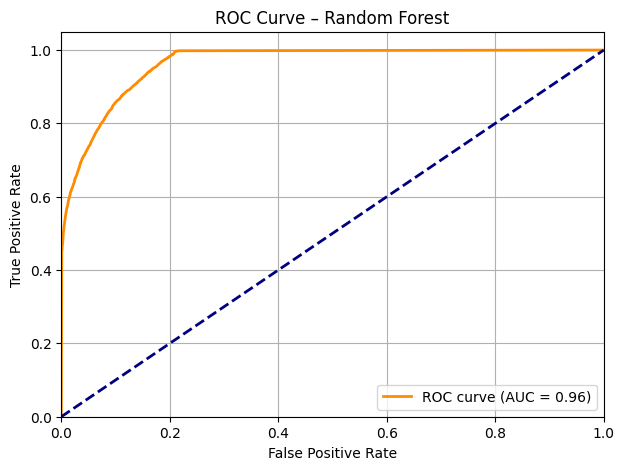

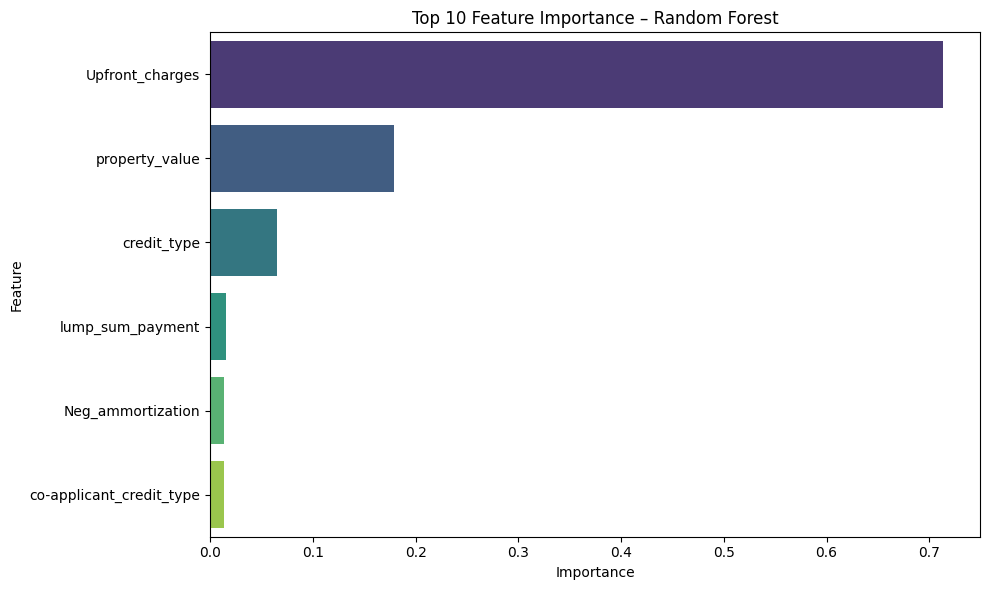

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, f1_score, roc_curve, auc
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Build & train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train, y_train)

# Predictions
y_pred_proba = rf.predict_proba(x_test)[:, 1]
y_pred = (y_pred_proba >= 0.6313).astype(int)

# Evaluation metrics
acc = accuracy_score(y_test, y_pred)
roc_auc_val = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print("Random Forest Model Performance")
print("=" * 60)
print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc_auc_val:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"Features : {x_train.shape[1]}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Confusion Matrix Heatmap
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix – Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve (still uses full probabilities)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_curve = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc_curve:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Feature Importance
importances = rf.feature_importances_
feat_names = X_scaled_df.columns  # Make sure X_scaled_df is your scaled DataFrame

feat_df = pd.DataFrame({
    'Feature'    : feat_names,
    'Importance' : importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feat_df.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importance – Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


[TEST] Best threshold (maximize F1): 0.6313
[TEST] Precision@best: 0.7433 | Recall@best: 0.8496 | F1@best: 0.7929

Evaluation on TEST with F1-selected threshold
Accuracy: 0.8908
ROC-AUC : 0.9630
F1      : 0.7929

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93     33312
           1       0.74      0.85      0.79     10871

    accuracy                           0.89     44183
   macro avg       0.85      0.88      0.86     44183
weighted avg       0.90      0.89      0.89     44183


Confusion Matrix:
[[30122  3190]
 [ 1635  9236]]


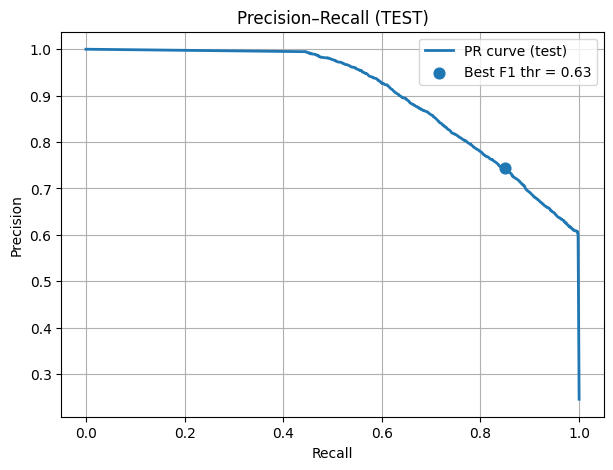


[TEST] Best threshold (ROC Youden's J): 0.0398 | TPR=0.9952 | FPR=0.2092

Evaluation on TEST with ROC-Youden threshold
Accuracy: 0.8411
ROC-AUC : 0.9630
F1      : 0.7550

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.79      0.88     33312
           1       0.61      1.00      0.76     10871

    accuracy                           0.84     44183
   macro avg       0.80      0.89      0.82     44183
weighted avg       0.90      0.84      0.85     44183


Confusion Matrix:
[[26343  6969]
 [   52 10819]]


In [52]:
# ===============================
# Find best threshold ON TEST SET
# ===============================
from sklearn.metrics import precision_recall_curve, roc_curve

# ---- Best threshold by F1 on test (from PR curve) ----
prec, rec, thr_pr = precision_recall_curve(y_test, y_pred_proba)  # len(thr_pr) = len(prec)-1
f1_vals = 2 * prec * rec / (prec + rec + 1e-12)

best_idx_f1 = np.argmax(f1_vals[:-1]) if len(thr_pr) else 0
best_thr_f1 = float(thr_pr[best_idx_f1]) if len(thr_pr) else 0.5
print(f"\n[TEST] Best threshold (maximize F1): {best_thr_f1:.4f}")
print(f"[TEST] Precision@best: {prec[best_idx_f1]:.4f} | Recall@best: {rec[best_idx_f1]:.4f} | F1@best: {f1_vals[best_idx_f1]:.4f}")

y_pred_best_f1 = (y_pred_proba >= best_thr_f1).astype(int)

print("\nEvaluation on TEST with F1-selected threshold")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_f1):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}")  # AUC unchanged by threshold
print(f"F1      : {f1_score(y_test, y_pred_best_f1):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_f1))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_f1))

# (Optional) visualize PR curve and best point
plt.figure(figsize=(7,5))
plt.plot(rec, prec, lw=2, label='PR curve (test)')
plt.scatter(rec[best_idx_f1], prec[best_idx_f1], s=60, marker='o',
            label=f'Best F1 thr = {best_thr_f1:.2f}', zorder=5)
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision–Recall (TEST)')
plt.legend(); plt.grid(True); plt.show()



##### Gradient Boosting


Gradient Boosting Model Performance (with Class Weight)
Accuracy: 0.8997
ROC-AUC Score: 0.9666
F1 Score: 0.8022
Number of features used: 6

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     33312
           1       0.78      0.83      0.80     10871

    accuracy                           0.90     44183
   macro avg       0.86      0.88      0.87     44183
weighted avg       0.90      0.90      0.90     44183


Confusion Matrix:
[[30764  2548]
 [ 1884  8987]]


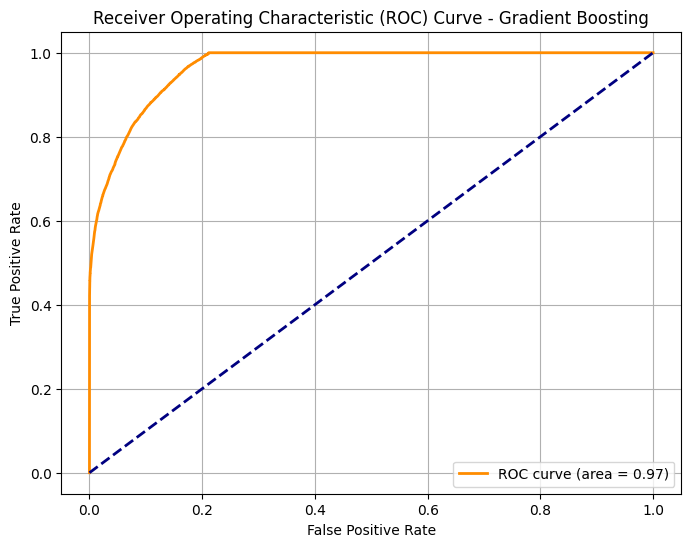

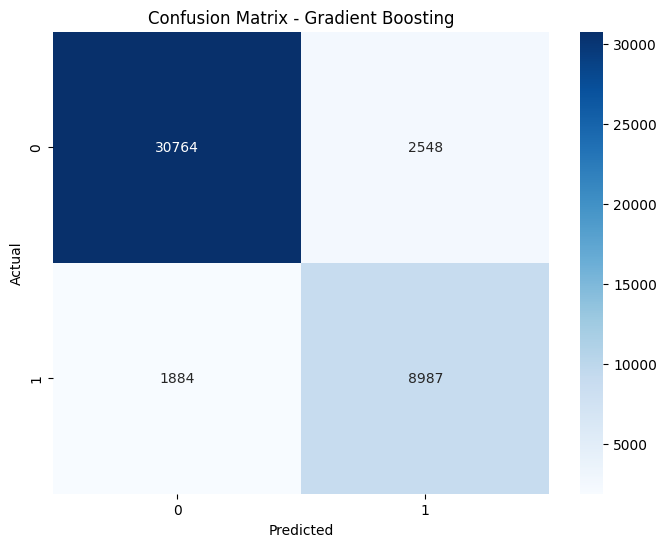

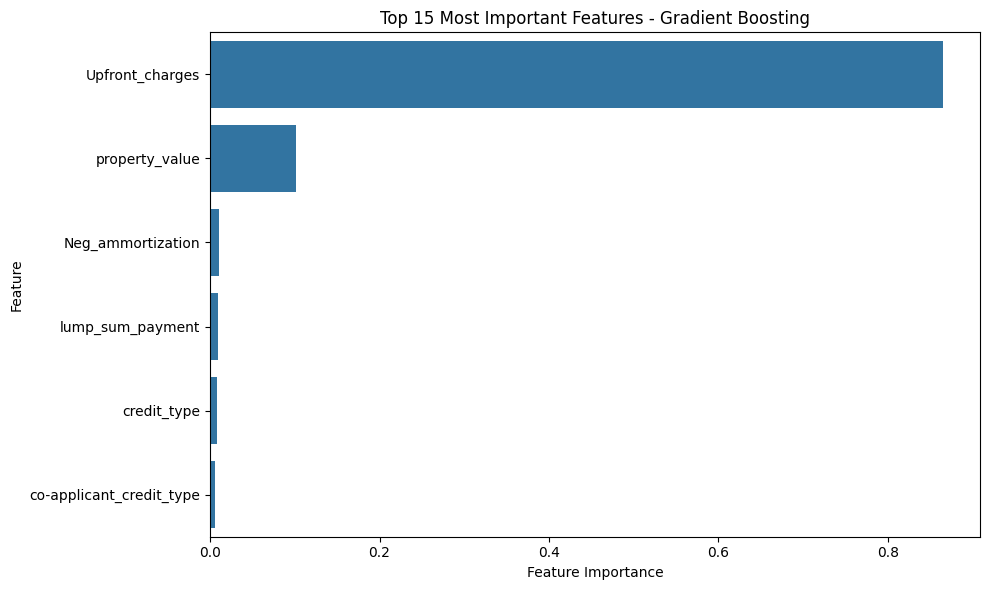

In [32]:
# ===============================================================
# Gradient Boosting Classifier for Imbalanced Dataset
# ===============================================================
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ===============================================================
# Build Gradient Boosting model
# ===============================================================
gb_model = GradientBoostingClassifier(
    n_estimators=300,       # number of trees
    learning_rate=0.1,     # learning rate (smaller = more robust)
    max_depth=6,            # limit tree depth to prevent overfitting
    subsample=0.8,          # random sampling for regularization
    random_state=42
)

# Since GradientBoostingClassifier does not support class_weight directly,
# we simulate it via sample_weight during training
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Fit model
gb_model.fit(x_train, y_train, sample_weight=sample_weights)

# ===============================================================
# Predictions
# ===============================================================
y_pred_proba = gb_model.predict_proba(x_test)[:, 1]
y_pred = (y_pred_proba >= 0.6896).astype(int)  # can adjust threshold

# ===============================================================
# Evaluation
# ===============================================================
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)

print("\nGradient Boosting Model Performance (with Class Weight)")
print("=" * 70)
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Number of features used: {len(selected_features)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ===============================================================
# ROC Curve
# ===============================================================
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Gradient Boosting')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ===============================================================
# Confusion Matrix
# ===============================================================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ===============================================================
# Feature Importance
# ===============================================================
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature')
plt.title('Top 15 Most Important Features - Gradient Boosting')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()



[TEST] Best threshold (maximize F1): 0.6896
[TEST] Precision@best: 0.7791 | Recall@best: 0.8267 | F1@best: 0.8022

Evaluation on TEST with F1-selected threshold
Accuracy: 0.8997
ROC-AUC : 0.9666
F1      : 0.8022

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     33312
           1       0.78      0.83      0.80     10871

    accuracy                           0.90     44183
   macro avg       0.86      0.88      0.87     44183
weighted avg       0.90      0.90      0.90     44183


Confusion Matrix:
[[30764  2548]
 [ 1884  8987]]


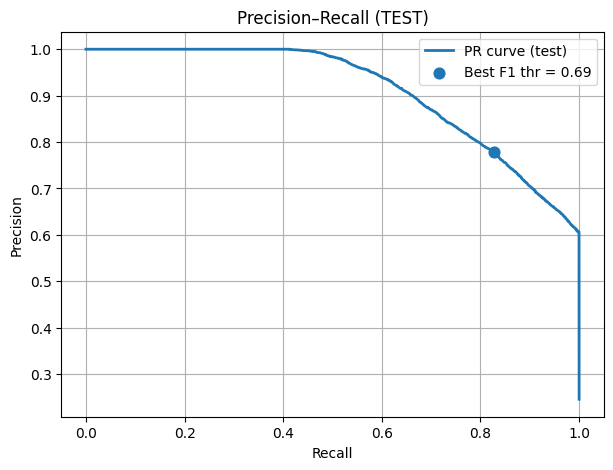

In [31]:
# ===============================
# Find best threshold ON TEST SET
# ===============================
from sklearn.metrics import precision_recall_curve, roc_curve

# ---- Best threshold by F1 on test (from PR curve) ----
prec, rec, thr_pr = precision_recall_curve(y_test, y_pred_proba)  # len(thr_pr) = len(prec)-1
f1_vals = 2 * prec * rec / (prec + rec + 1e-12)

best_idx_f1 = np.argmax(f1_vals[:-1]) if len(thr_pr) else 0
best_thr_f1 = float(thr_pr[best_idx_f1]) if len(thr_pr) else 0.5
print(f"\n[TEST] Best threshold (maximize F1): {best_thr_f1:.4f}")
print(f"[TEST] Precision@best: {prec[best_idx_f1]:.4f} | Recall@best: {rec[best_idx_f1]:.4f} | F1@best: {f1_vals[best_idx_f1]:.4f}")

y_pred_best_f1 = (y_pred_proba >= best_thr_f1).astype(int)

print("\nEvaluation on TEST with F1-selected threshold")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_f1):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}")  # AUC unchanged by threshold
print(f"F1      : {f1_score(y_test, y_pred_best_f1):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_f1))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_f1))

# (Optional) visualize PR curve and best point
plt.figure(figsize=(7,5))
plt.plot(rec, prec, lw=2, label='PR curve (test)')
plt.scatter(rec[best_idx_f1], prec[best_idx_f1], s=60, marker='o',
            label=f'Best F1 thr = {best_thr_f1:.2f}', zorder=5)
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision–Recall (TEST)')
plt.legend(); plt.grid(True); plt.show()



#### LGBM

[LightGBM] [Info] Number of positive: 25253, number of negative: 77838
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010873 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 524
[LightGBM] [Info] Number of data points in the train set: 103091, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

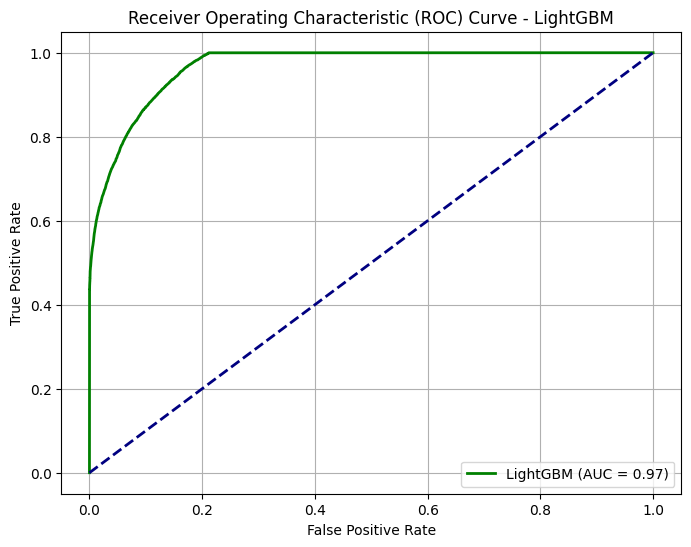

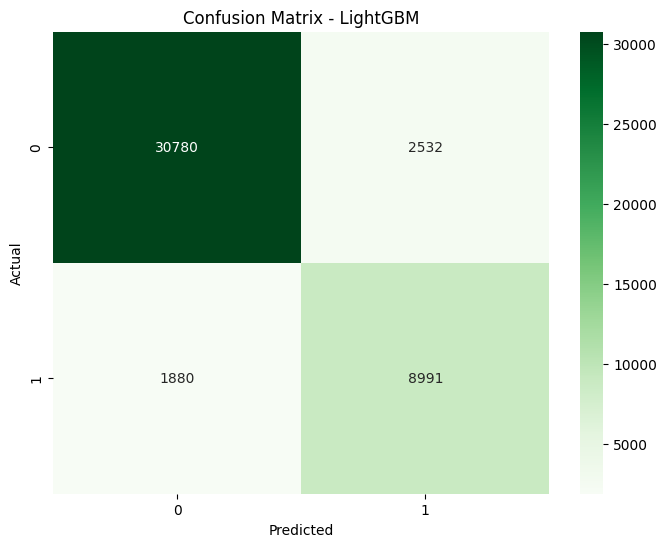

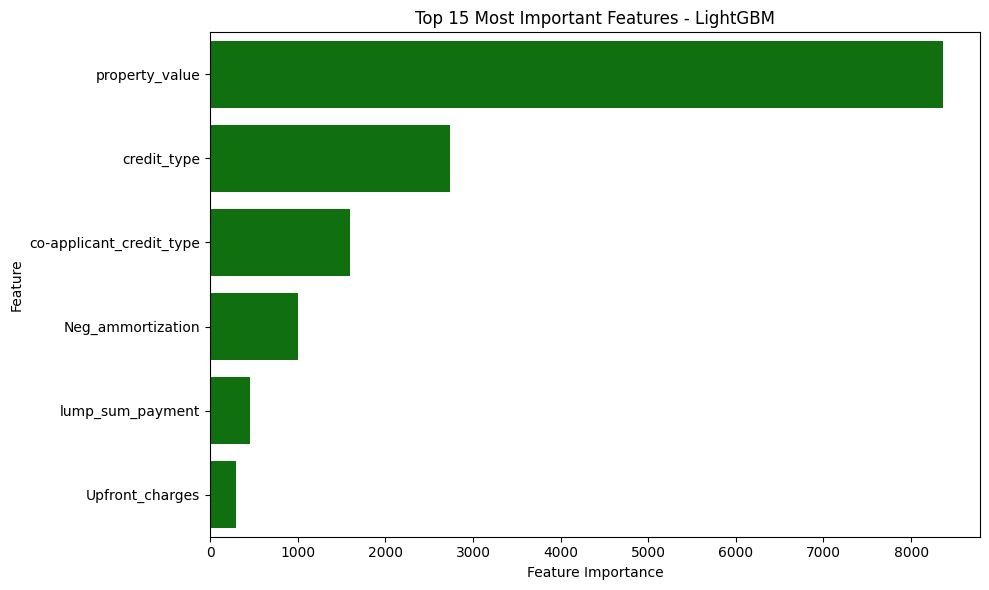


===================== Model Comparison Summary =====================
Model                Accuracy     ROC-AUC      F1 Score    
Gradient Boosting    0.8997      0.9666      0.8022
LightGBM             0.9001      0.9672      0.8030


In [38]:
# ===============================================================
# LightGBM Classifier for Imbalanced Dataset
# ===============================================================
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ===============================================================
# Build LightGBM model
# ===============================================================
lgb_model = LGBMClassifier(
    n_estimators=500,            # số lượng cây (nhiều hơn chút vì LightGBM nhanh)
    learning_rate=0.05,          # learning rate nhỏ hơn để học mượt hơn
    max_depth=-1,                # -1 = không giới hạn độ sâu (LightGBM tự tối ưu)
    num_leaves=31,               # số lá trong mỗi cây (tăng = dễ overfit)
    subsample=0.8,               # random sampling để tránh overfitting
    colsample_bytree=0.8,        # dùng 80% features cho mỗi cây
    class_weight='balanced',     # tự động cân bằng các lớp (rất hữu ích cho imbalanced dataset)
    random_state=42,
    boosting_type='gbdt'         # standard Gradient Boosting Decision Tree
)

# Fit model
lgb_model.fit(x_train, y_train)

# ===============================================================
# Predictions
# ===============================================================
y_pred_proba_lgb = lgb_model.predict_proba(x_test)[:, 1]
y_pred_lgb = (y_pred_proba_lgb >= 0.6831).astype(int)  # threshold có thể điều chỉnh

# ===============================================================
# Evaluation
# ===============================================================
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
roc_auc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)

print("\nLightGBM Model Performance (with Class Weight)")
print("=" * 70)
print(f"Accuracy: {accuracy_lgb:.4f}")
print(f"ROC-AUC Score: {roc_auc_lgb:.4f}")
print(f"F1 Score: {f1_lgb:.4f}")
print(f"Number of features used: {len(selected_features)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lgb))

# ===============================================================
# ROC Curve
# ===============================================================
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_pred_proba_lgb)
roc_auc_value_lgb = auc(fpr_lgb, tpr_lgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lgb, tpr_lgb, color='green', lw=2, label=f'LightGBM (AUC = {roc_auc_value_lgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - LightGBM')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ===============================================================
# Confusion Matrix
# ===============================================================
plt.figure(figsize=(8, 6))
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - LightGBM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ===============================================================
# Feature Importance
# ===============================================================
feature_importance_lgb = pd.DataFrame({
    'Feature': selected_features,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_lgb.head(15), x='Importance', y='Feature', color='green')
plt.title('Top 15 Most Important Features - LightGBM')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ===============================================================
# Compare Models Summary
# ===============================================================
print("\n===================== Model Comparison Summary =====================")
print(f"{'Model':<20} {'Accuracy':<12} {'ROC-AUC':<12} {'F1 Score':<12}")
print("=" * 60)
print(f"{'Gradient Boosting':<20} {accuracy:.4f}      {roc_auc:.4f}      {f1:.4f}")
print(f"{'LightGBM':<20} {accuracy_lgb:.4f}      {roc_auc_lgb:.4f}      {f1_lgb:.4f}")
print("=" * 60)


[TEST] Best threshold (maximize F1): 0.6831
[TEST] Precision@best: 0.7803 | Recall@best: 0.8271 | F1@best: 0.8030

Evaluation on TEST with F1-selected threshold
Accuracy: 0.8991
ROC-AUC : 0.9666
F1      : 0.8018

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93     33312
           1       0.78      0.83      0.80     10871

    accuracy                           0.90     44183
   macro avg       0.86      0.88      0.87     44183
weighted avg       0.90      0.90      0.90     44183


Confusion Matrix:
[[30714  2598]
 [ 1858  9013]]


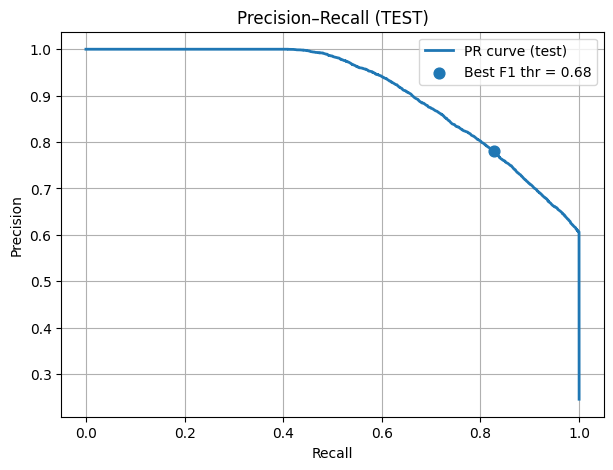

In [37]:
# ===============================
# Find best threshold ON TEST SET
# ===============================
from sklearn.metrics import precision_recall_curve, roc_curve

# ---- Best threshold by F1 on test (from PR curve) ----
prec, rec, thr_pr = precision_recall_curve(y_test, y_pred_proba_lgb)  # len(thr_pr) = len(prec)-1
f1_vals = 2 * prec * rec / (prec + rec + 1e-12)

best_idx_f1 = np.argmax(f1_vals[:-1]) if len(thr_pr) else 0
best_thr_f1 = float(thr_pr[best_idx_f1]) if len(thr_pr) else 0.5
print(f"\n[TEST] Best threshold (maximize F1): {best_thr_f1:.4f}")
print(f"[TEST] Precision@best: {prec[best_idx_f1]:.4f} | Recall@best: {rec[best_idx_f1]:.4f} | F1@best: {f1_vals[best_idx_f1]:.4f}")

y_pred_best_f1 = (y_pred_proba >= best_thr_f1).astype(int)

print("\nEvaluation on TEST with F1-selected threshold")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_best_f1):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}")  # AUC unchanged by threshold
print(f"F1      : {f1_score(y_test, y_pred_best_f1):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_f1))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_f1))

# (Optional) visualize PR curve and best point
plt.figure(figsize=(7,5))
plt.plot(rec, prec, lw=2, label='PR curve (test)')
plt.scatter(rec[best_idx_f1], prec[best_idx_f1], s=60, marker='o',
            label=f'Best F1 thr = {best_thr_f1:.2f}', zorder=5)
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision–Recall (TEST)')
plt.legend(); plt.grid(True); plt.show()



#### ANN

Epoch 1/150
645/645 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8143 - loss: 0.3935 - val_accuracy: 0.8908 - val_loss: 0.2060
Epoch 2/150
645/645 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8889 - loss: 0.2214 - val_accuracy: 0.8963 - val_loss: 0.1985
Epoch 3/150
645/645 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8927 - loss: 0.2099 - val_accuracy: 0.8978 - val_loss: 0.1987
Epoch 4/150
645/645 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8965 - loss: 0.2035 - val_accuracy: 0.8996 - val_loss: 0.1955
Epoch 5/150
645/645 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8957 - loss: 0.2000 - val_accuracy: 0.9005 - val_loss: 0.1900
Epoch 6/150
645/645 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8986 - loss: 0.1957 - val_accuracy: 0.9005 - val_loss: 0.1901
Epoch 7/150
645/645 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8980 - loss: 0.1958 - val_accuracy: 0.9010 - val_loss: 0.1889
Epoch 8/150
645/645 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8989 - loss: 0.1946 - val_ac

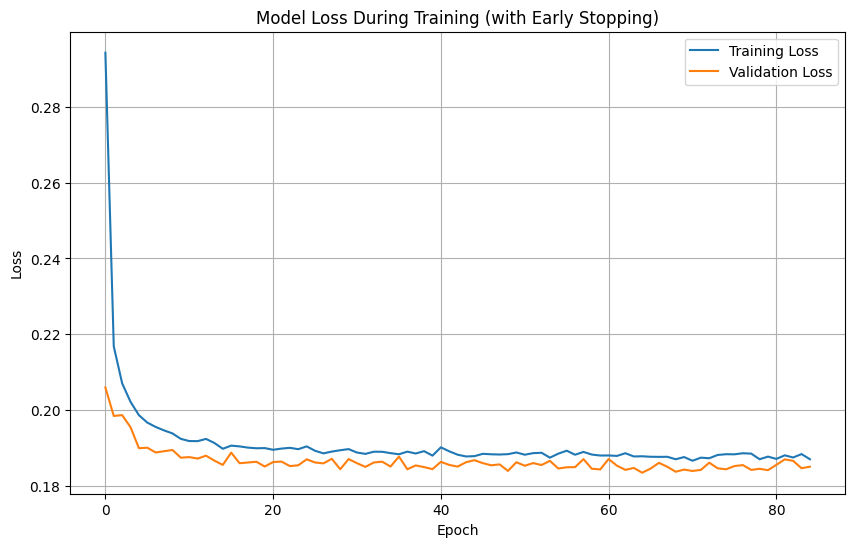

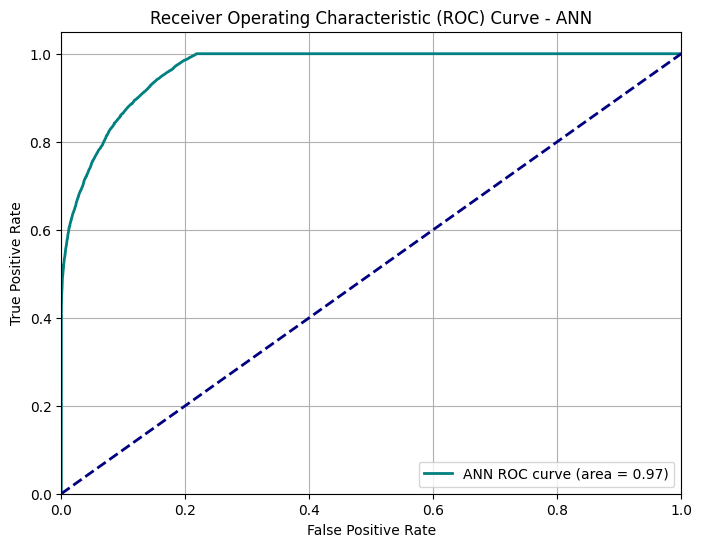

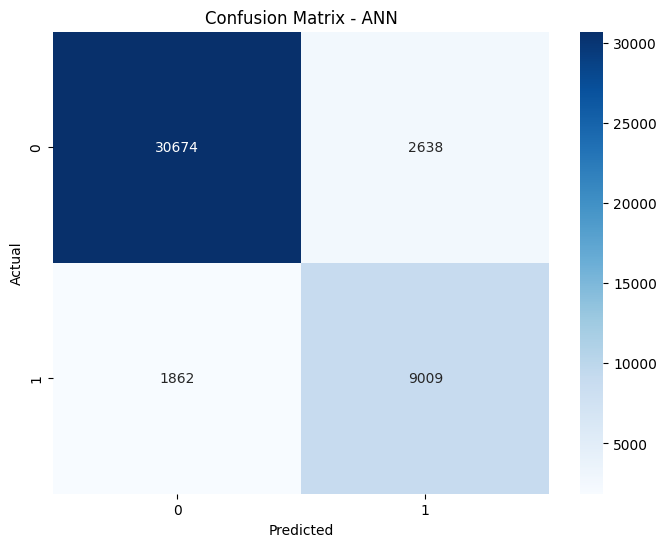

In [ ]:
# Additional imports for ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam # Import Adam optimizer

# Build ANN model with reduced complexity and higher dropout
ann_model = Sequential([
    Dense(256, activation='relu', input_shape=(x_train.shape[1],)),
    #Dropout(0.4),
    #Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(16, activation='relu'),
    Dropout(0.1),
    Dense(8, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

# Compile model
ann_model.compile(optimizer= Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping with adjusted parameters
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# Train model
history = ann_model.fit(x_train, y_train,
                       validation_split=0.2,
                       epochs=150,
                       batch_size=128,
                       callbacks=[early_stopping],
                       verbose=1)

# Predict
y_pred_proba_ann = ann_model.predict(x_test)
y_pred_ann = (y_pred_proba_ann >= 0.4).astype(int)

# Evaluate model
accuracy_ann = accuracy_score(y_test, y_pred_ann)
roc_auc_ann = roc_auc_score(y_test, y_pred_proba_ann)
f1_ann = f1_score(y_test, y_pred_ann)

print("\nArtificial Neural Network Model Performance (with Regularization)")
print("=" * 50)
print(f"Accuracy: {accuracy_ann:.4f}")
print(f"ROC-AUC Score: {roc_auc_ann:.4f}")
print(f"F1 Score: {f1_ann:.4f}")
print(f"Number of features used: {len(selected_features)}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

# Plot training history to check for overfitting
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training (with Early Stopping)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot ROC Curve
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_pred_proba_ann)
roc_auc_value_ann = auc(fpr_ann, tpr_ann)

plt.figure(figsize=(8, 6))
plt.plot(fpr_ann, tpr_ann, color='teal', lw=2, label=f'ANN ROC curve (area = {roc_auc_value_ann:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - ANN')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm_ann = confusion_matrix(y_test, y_pred_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - ANN')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()